# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 2    |  |
| :-------------|:-------------|
| Isha Schneiders| 6384838 |
| Thibo Alders| 6581390 |
| Wout Zeilmaker| 6585043|

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['wout', 'isha']

## Opdracht 1: Planning.

| Planning Groep: 2     |Tijdstip / Tijdspanne  |
|---|---|
| kalibratie metingen | 11.00-11.15 |
| eigen algortime uitvoeren en ontwerpen | 11.15-12.30, 13.45-14.15 |
| algortime kiezen,testen en itereren | 14.15-16.30 |
| TU Pauze 1| 12.30-13.30 |


## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [2]
<img src="kalibratie opstelling echo.jpeg" width="400">

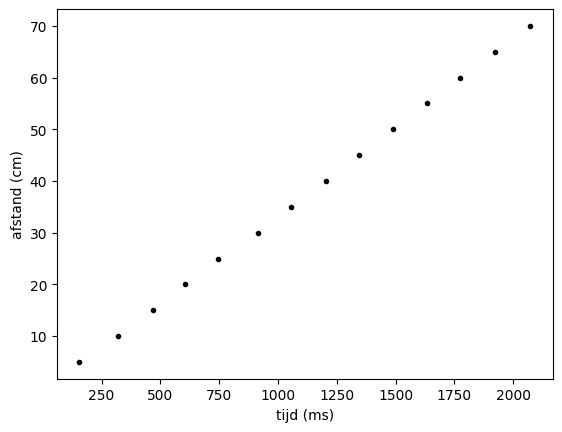

[ 0.03412922 -0.79298199]


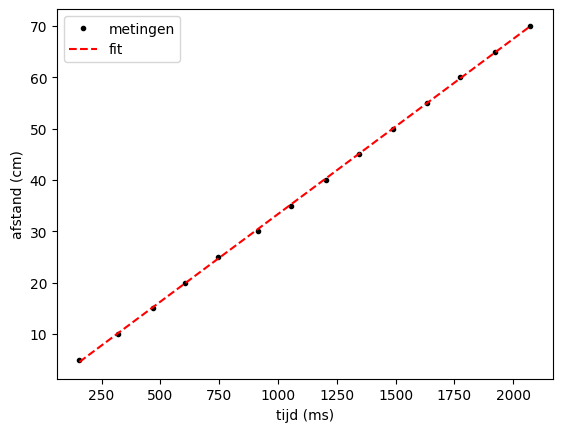

In [3]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

afstand=np.array([30,15,45,60,70,5,10,20,25,35,40,50,55,65]) #cm
tijd=np.array([915,468,1345,1774,2073,156,318,606,747,1057,1206,1488,1634,1921]) #ms

def lijn(x,a,b):
    return a*x+b

plt.figure()
plt.plot(tijd,afstand,"k.")
plt.xlabel('tijd (ms)')
plt.ylabel('afstand (cm)')
plt.show()

val,cov=curve_fit(lijn,tijd,afstand)
print(val)
x_plot=np.linspace(min(tijd),max(tijd))

plt.figure()
plt.plot(tijd,afstand,"k.",label="metingen")
plt.plot(x_plot,lijn(x_plot,*val),"r--",label="fit")
plt.xlabel('tijd (ms)')
plt.ylabel('afstand (cm)')
plt.legend()
plt.show()


## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  44.6
1   0  30   0  20  44.6
2  40   0  30   0  43.2
3  30   0  20   0  43.1


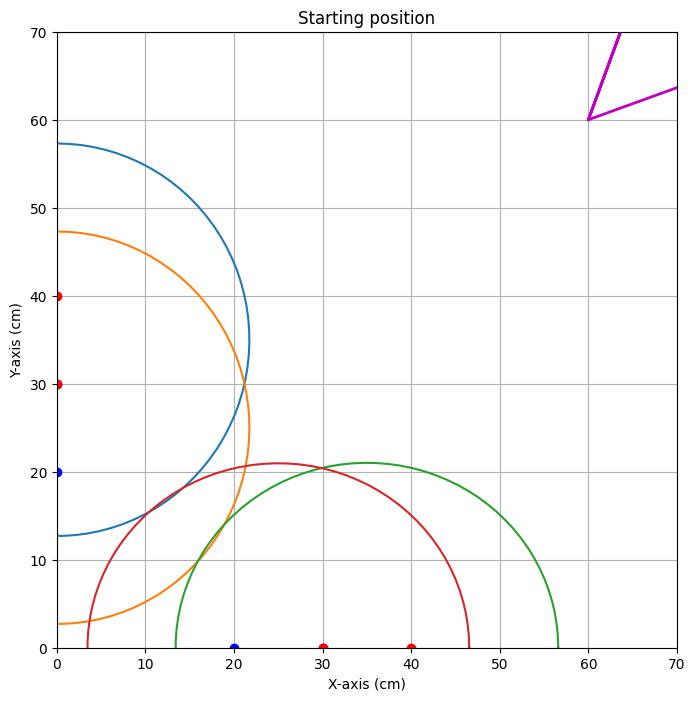


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=98.080


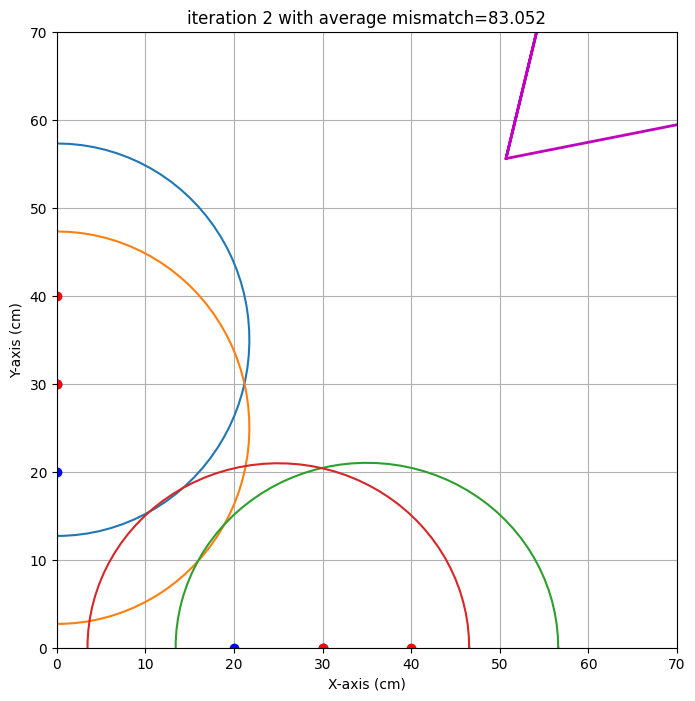

end iteration 2 with average mismatch=83.052


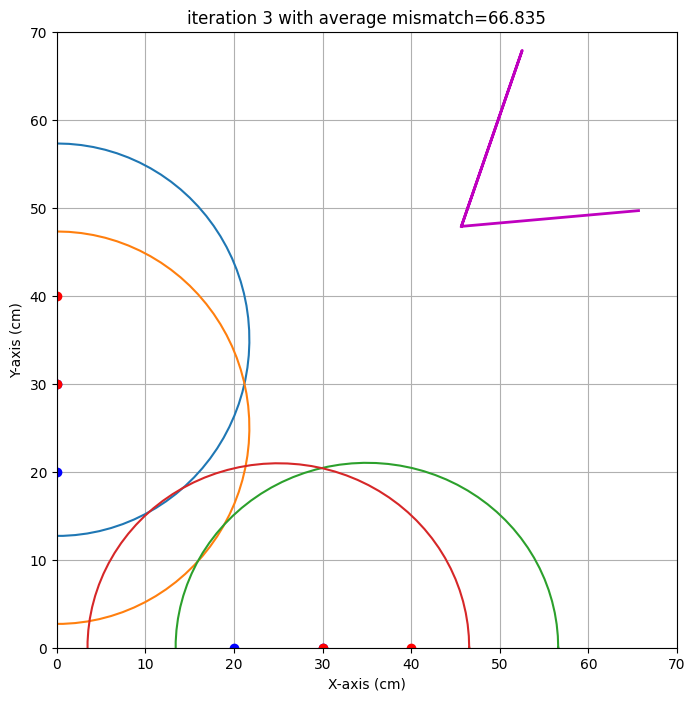

end iteration 3 with average mismatch=66.835


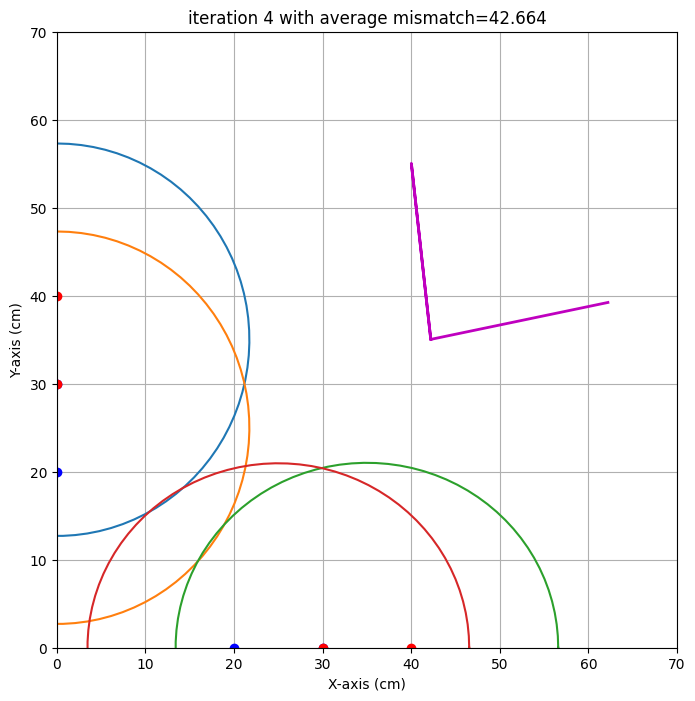

end iteration 4 with average mismatch=42.664


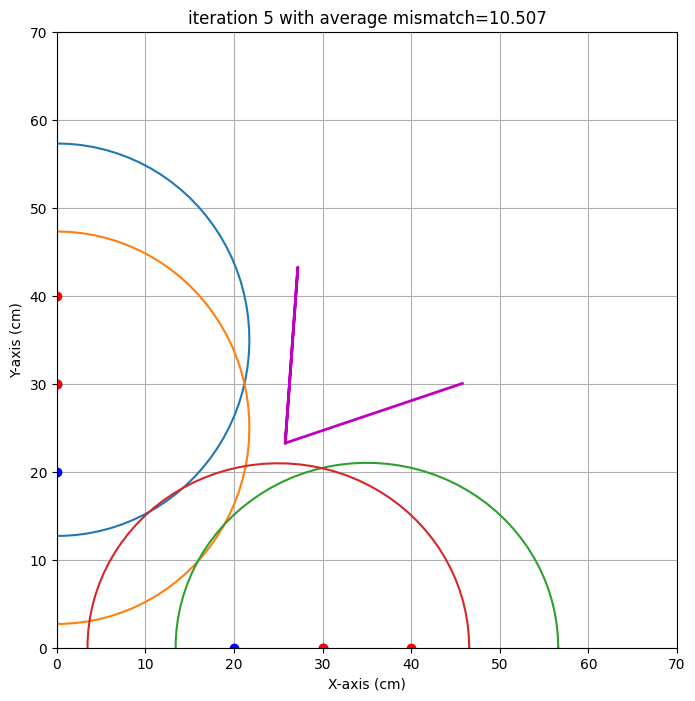

end iteration 5 with average mismatch=10.507


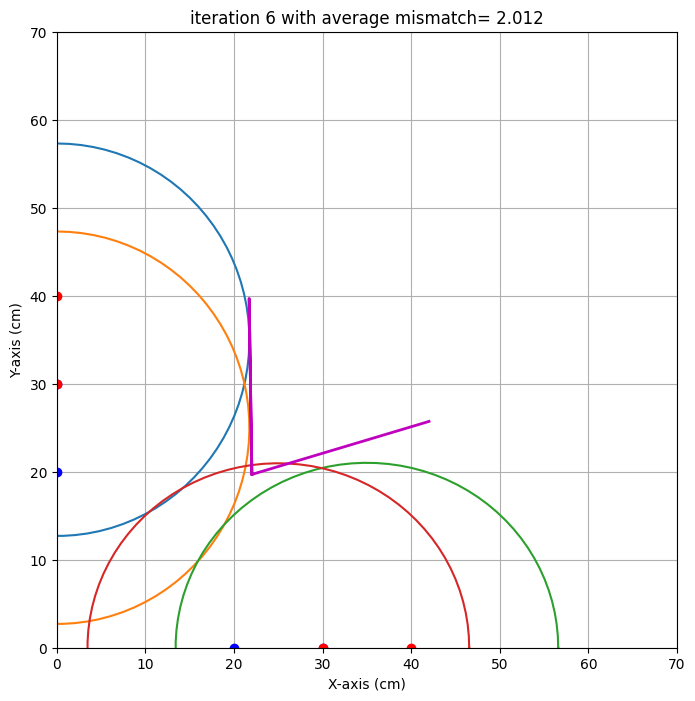

end iteration 6 with average mismatch= 2.012


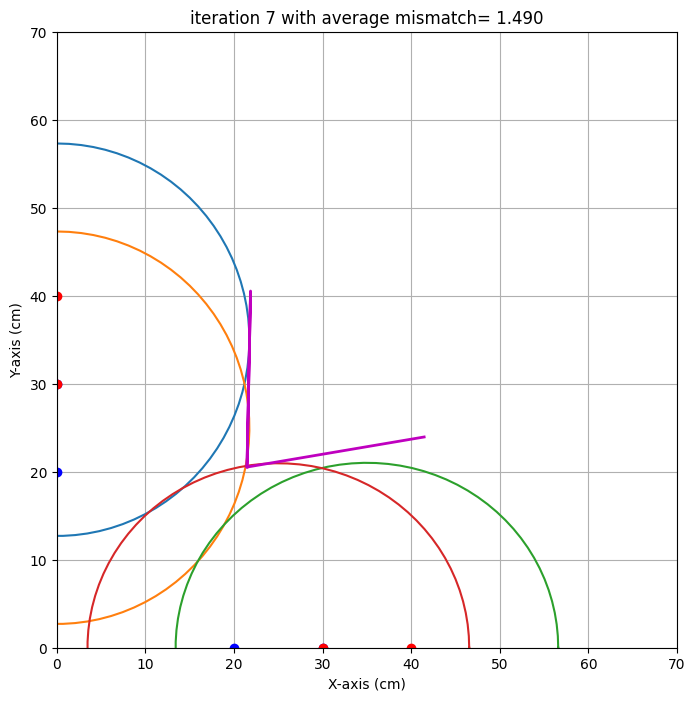

end iteration 7 with average mismatch= 1.490


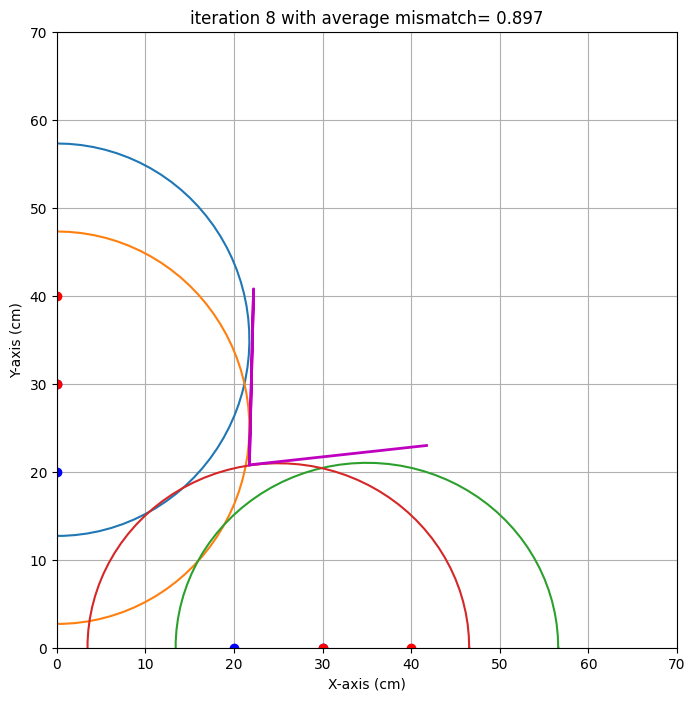

end iteration 8 with average mismatch= 0.897


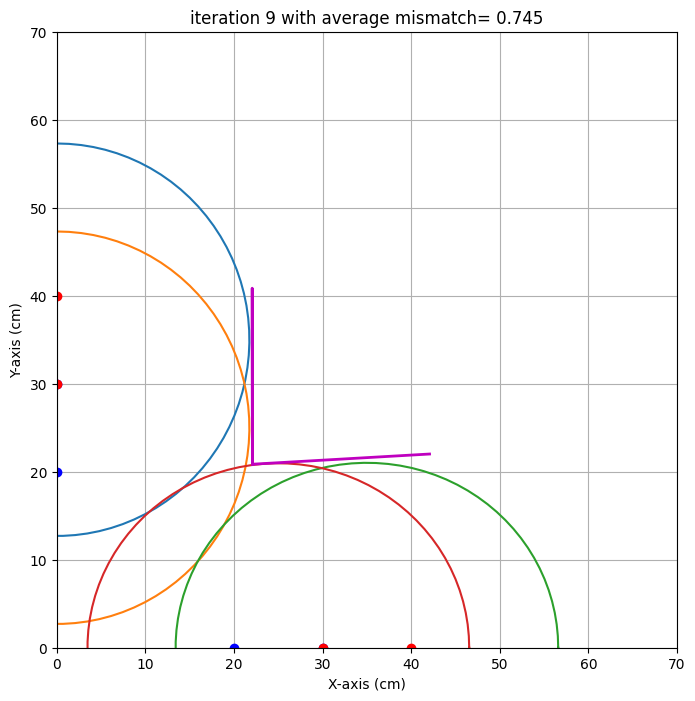

end iteration 9 with average mismatch= 0.745


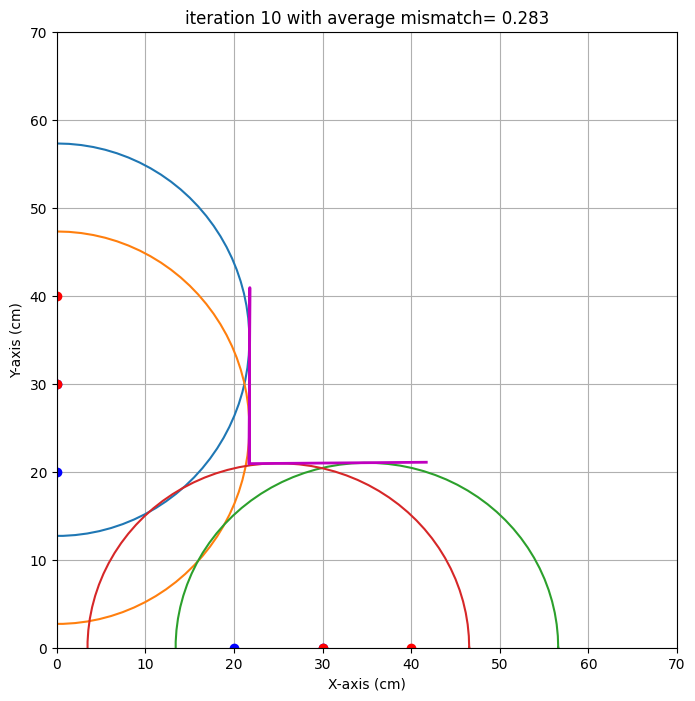

end iteration 10 with average mismatch= 0.283


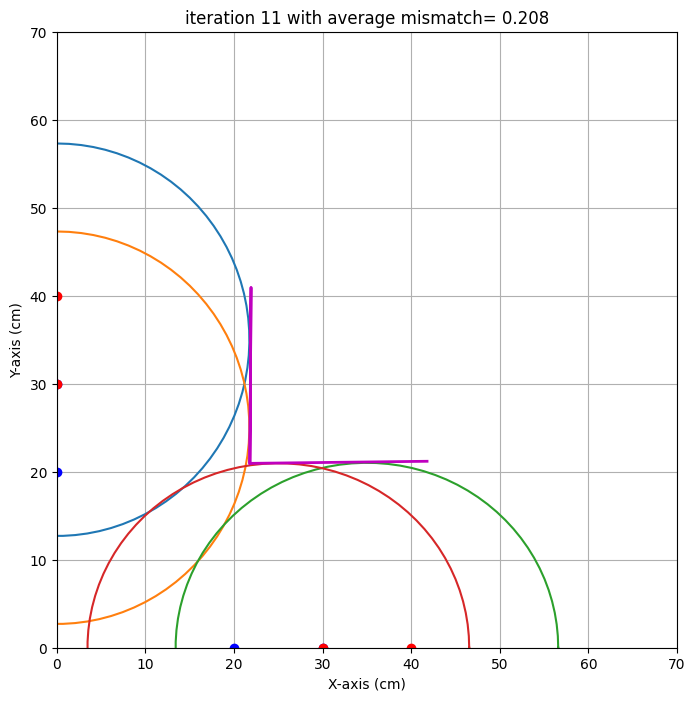

end iteration 11 with average mismatch= 0.208
end iteration 12 with average mismatch= 0.206
end iteration 13 with average mismatch= 0.192
end iteration 14 with average mismatch= 0.192
end iteration 15 with average mismatch= 0.192
end iteration 16 with average mismatch= 0.192
end iteration 17 with average mismatch= 0.192
end iteration 18 with average mismatch= 0.192
end iteration 19 with average mismatch= 0.192


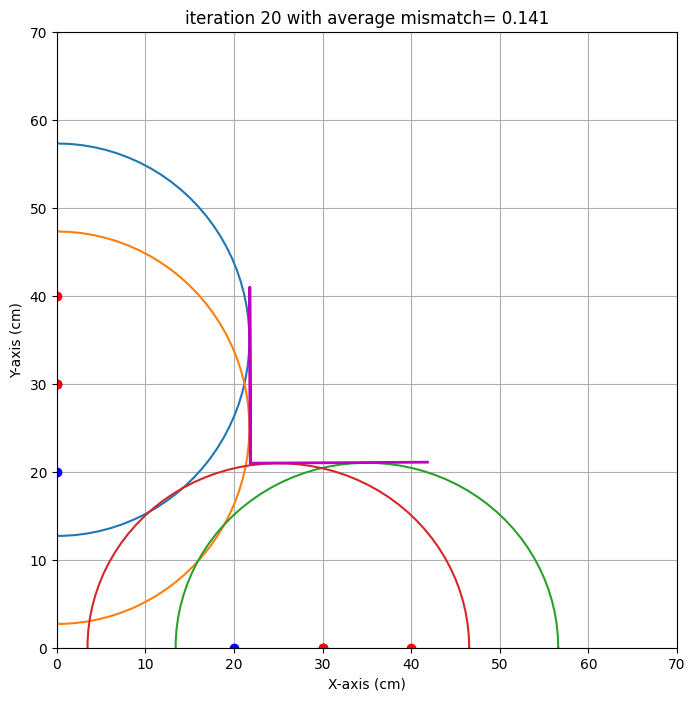

end iteration 20 with average mismatch= 0.141


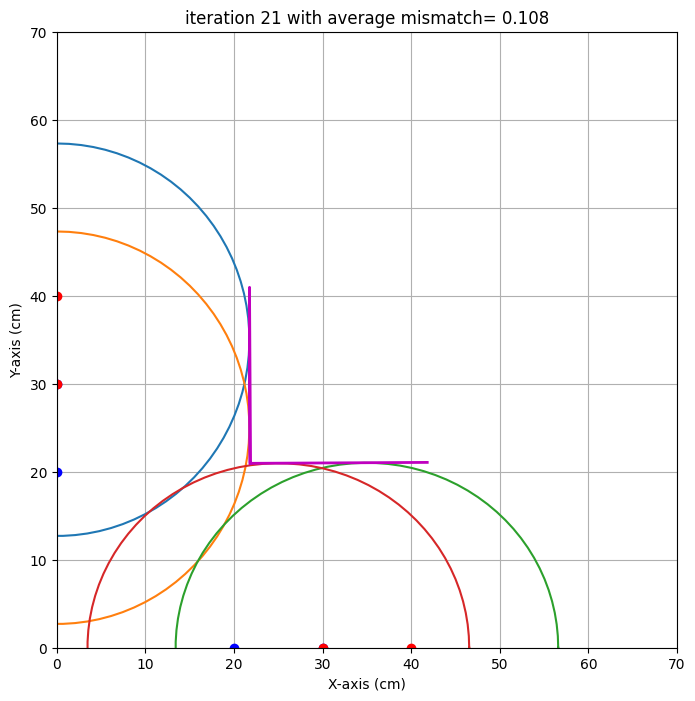

end iteration 21 with average mismatch= 0.108
end iteration 22 with average mismatch= 0.098
end iteration 23 with average mismatch= 0.098
end iteration 24 with average mismatch= 0.098
end iteration 25 with average mismatch= 0.098
end iteration 26 with average mismatch= 0.098
end iteration 27 with average mismatch= 0.098
end iteration 28 with average mismatch= 0.098
end iteration 29 with average mismatch= 0.098
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.098
###############################################################################
end of iteration  30
Best alpha=   0.29 with uncertainty=   0.00
Best beta =  -0.18 with uncertainty=   0.00
Best x0   =  21.79 with uncertainty=   0.00
Best y0   =  20.94 with uncertainty=   0.00
###############################################################################
no uncertainty found, pl

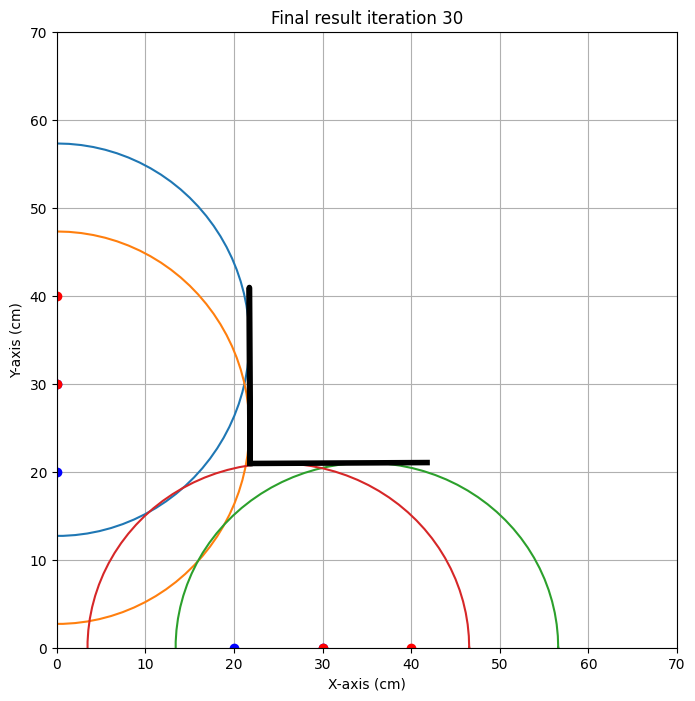

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,44.60],
    [0,30,0,20,44.60],
    #[0,10,0,20,49.7],
    [40,0,30,0,43.2],
    [30,0,20,0,43.1],
    #[10,0,20,0,51.3],
    #[10,0,0,10,18.1]hoek    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 21.8 cm met een standaardafwijking van 0.0 cm 
y0: 20.9 cm met een standaardafwijking van 0.0 cm 
alpha: 0.3 graden met een standaardafwijking van 0.0 graad 
beta: -0.2 graden met een standaardafwijking van 0.0 graad 



## Opdracht 5: Iteratie 0

#### algoritme [isha]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="algoritme isha.jpeg" width="400">

#### algoritme [wout]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="algortime wout.jpeg" width="400">

#### algoritme [thibo]
Voeg een foto in van het algoritme van het derde groepslid
<img src="algortime thibo.jpeg" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':52,  #zelf aanvullen,
           'y0':37,
           'alpha' :0, #zelf aanvullen,
           'beta' : 25, #zelf aanvullen},
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'wout' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #zelf aanvullen
    #[0,10,0,20,119.5],
    [0,40,0,50,104],
    #[30,0,20,0,199],
    [70,0,60,0,81.2],
    [65,0,55,0,77.7],
    [60,0,50,0,77.29],
    [0,45,0,55,105],
    [0,35,0,45,105.25],
    ]),
       
       
       'isha' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #zelf aanvullen
    #[0,20,0,30,110],
    [0,40,0,50,105],
    [0,35,0,45,104.7],
    [0,45,0,55,105.7],
    [47,0,57,0,79.0],
    [52,0,62,0,77.26],
    #[42,0,52,0,82.9],
    ]),
      }

## Opdracht 7: Evaluatie.

wout
Running the imaging algorithm with the following data:
   xs  ys  xr  yr       R
0   0  40   0  50  104.00
1  70   0  60   0   81.20
2  65   0  55   0   77.70
3  60   0  50   0   77.29
4   0  45   0  55  105.00
5   0  35   0  45  105.25


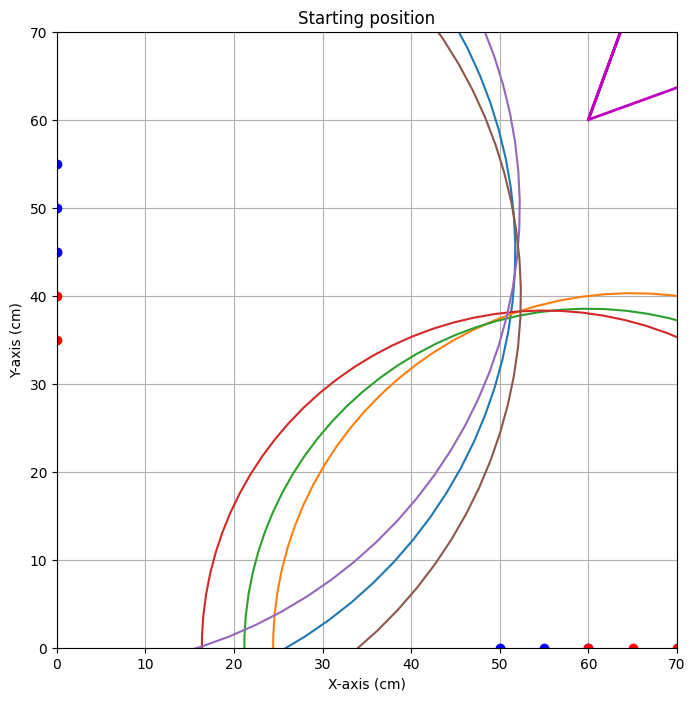


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=37.127


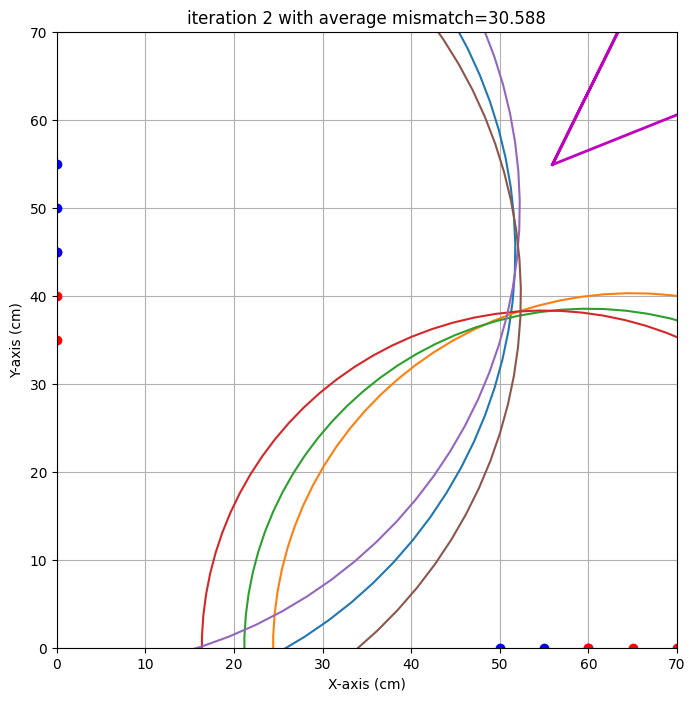

end iteration 2 with average mismatch=30.588


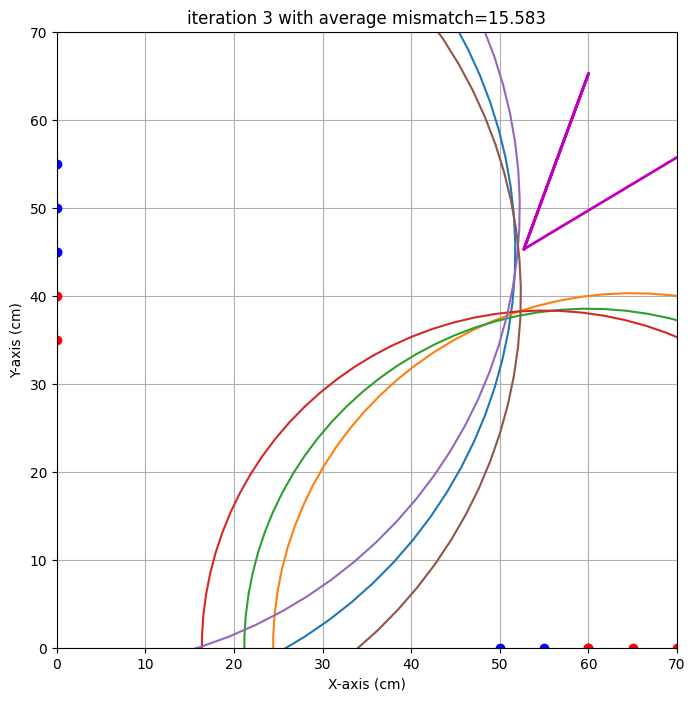

end iteration 3 with average mismatch=15.583


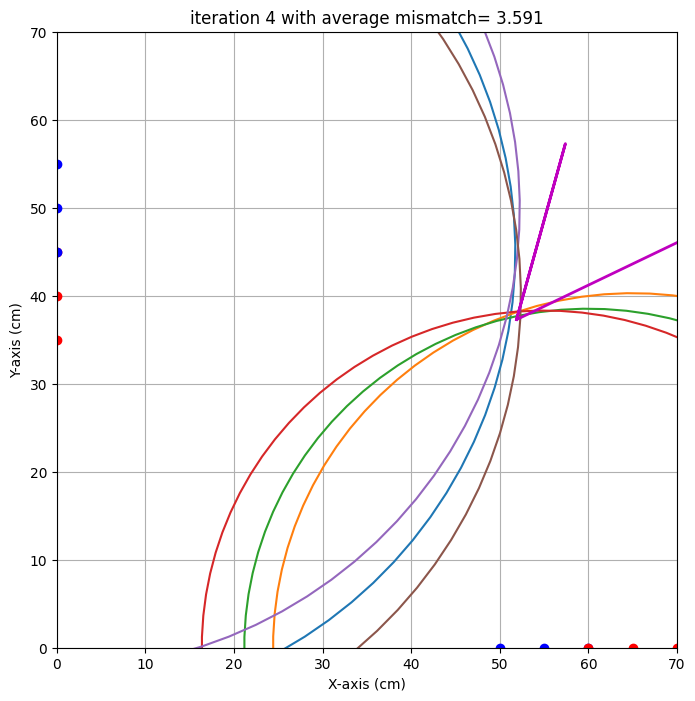

end iteration 4 with average mismatch= 3.591


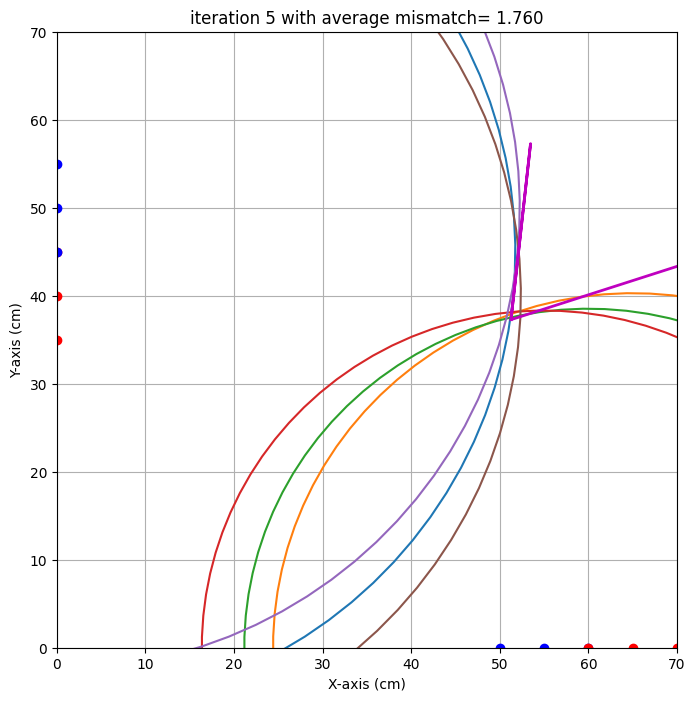

end iteration 5 with average mismatch= 1.760
end iteration 6 with average mismatch= 1.699
end iteration 7 with average mismatch= 1.635
end iteration 8 with average mismatch= 1.633
end iteration 9 with average mismatch= 1.581
end iteration 10 with average mismatch= 1.570
end iteration 11 with average mismatch= 1.569


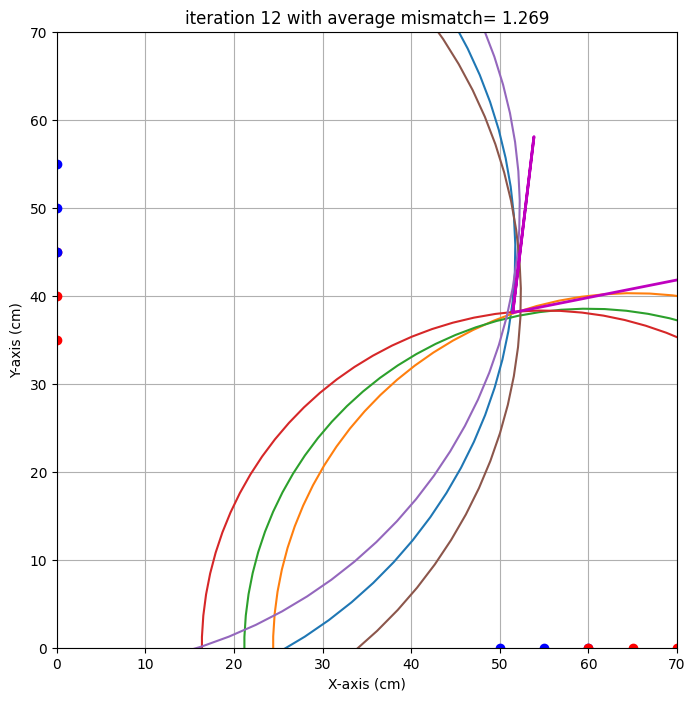

end iteration 12 with average mismatch= 1.269
end iteration 13 with average mismatch= 1.223
end iteration 14 with average mismatch= 1.223
end iteration 15 with average mismatch= 1.178
end iteration 16 with average mismatch= 1.178
end iteration 17 with average mismatch= 1.101
end iteration 18 with average mismatch= 1.097
end iteration 19 with average mismatch= 1.097
end iteration 20 with average mismatch= 1.097
end iteration 21 with average mismatch= 1.097


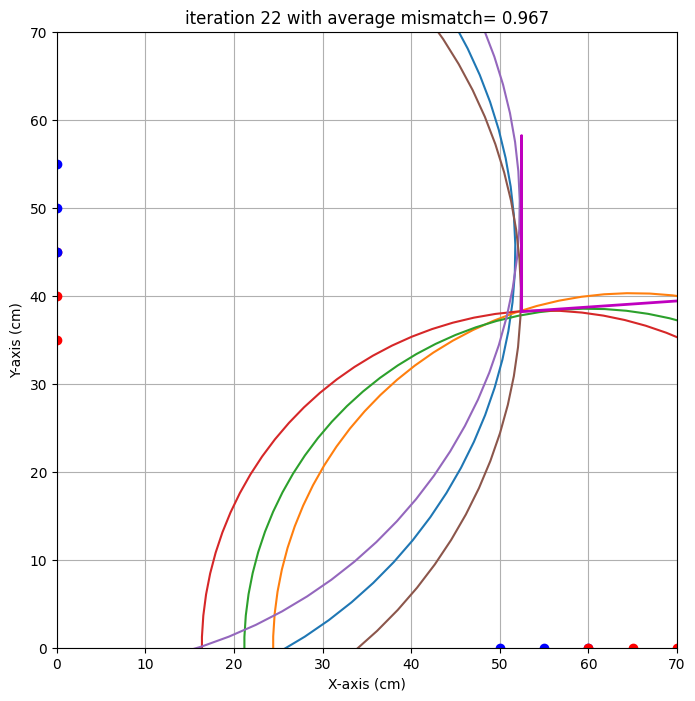

end iteration 22 with average mismatch= 0.967
end iteration 23 with average mismatch= 0.962
end iteration 24 with average mismatch= 0.959
end iteration 25 with average mismatch= 0.957


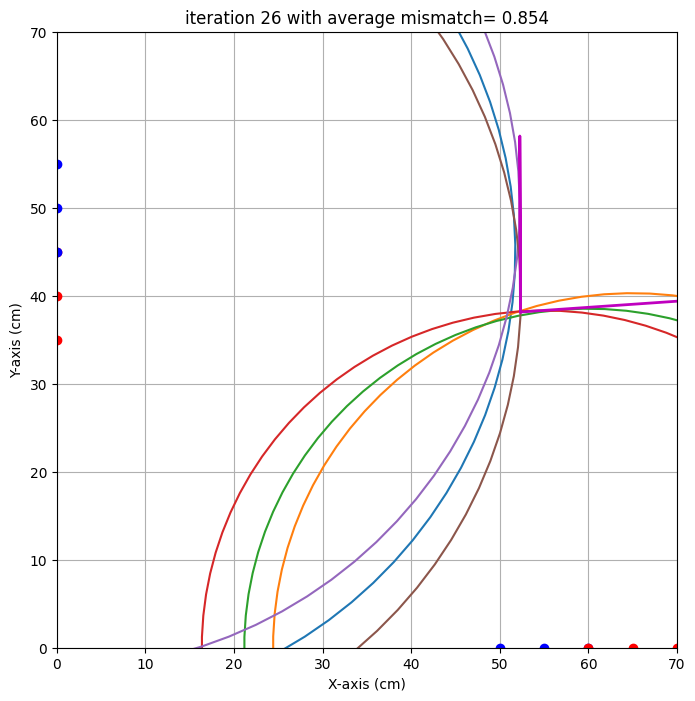

end iteration 26 with average mismatch= 0.854
end iteration 27 with average mismatch= 0.854
end iteration 28 with average mismatch= 0.854
end iteration 29 with average mismatch= 0.854
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.854
###############################################################################
end of iteration  30
Best alpha=   3.98 with uncertainty=   6.90
Best beta =  -0.20 with uncertainty=   7.01
Best x0   =  52.34 with uncertainty=   1.11
Best y0   =  38.15 with uncertainty=   0.47
###############################################################################


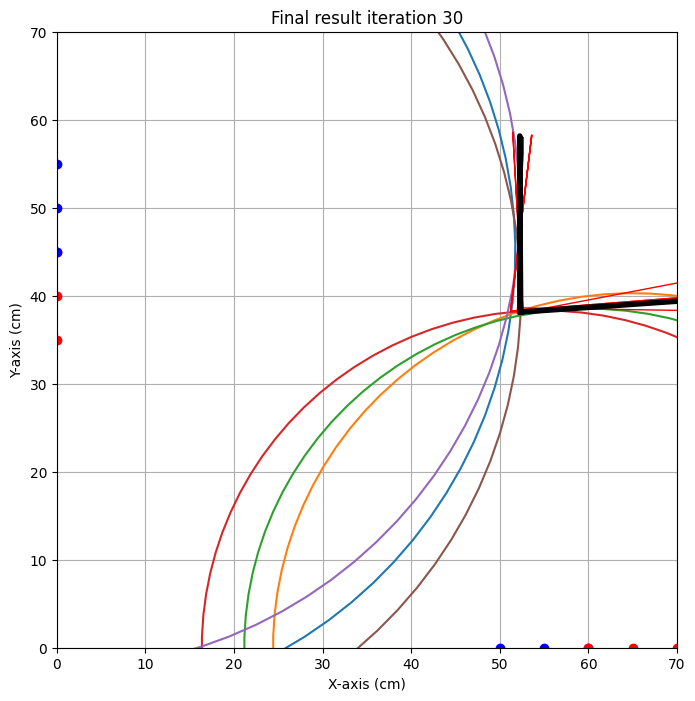

{'alpha': np.float64(3.9832610273482034), 'alpha_eps': np.float64(6.904218603877012), 'beta': np.float64(-0.2030052521683961), 'beta_eps': np.float64(7.013742841158134), 'x0': np.float64(52.336068530031184), 'x0_eps': np.float64(1.1138979162226335), 'y0': np.float64(38.14609028165537), 'y0_eps': np.float64(0.46716240696503064)}
isha
Running the imaging algorithm with the following data:
   xs  ys  xr  yr       R
0   0  40   0  50  105.00
1   0  35   0  45  104.70
2   0  45   0  55  105.70
3  47   0  57   0   79.00
4  52   0  62   0   77.26


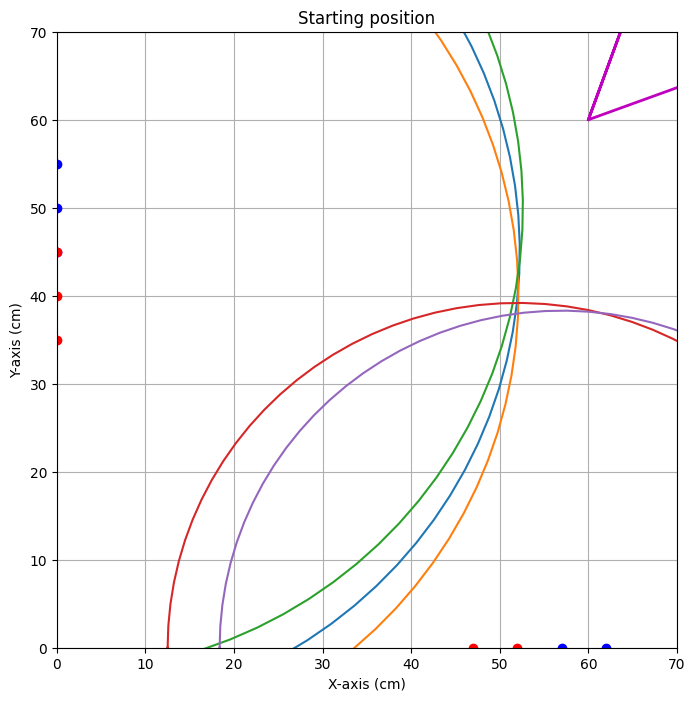


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=34.585


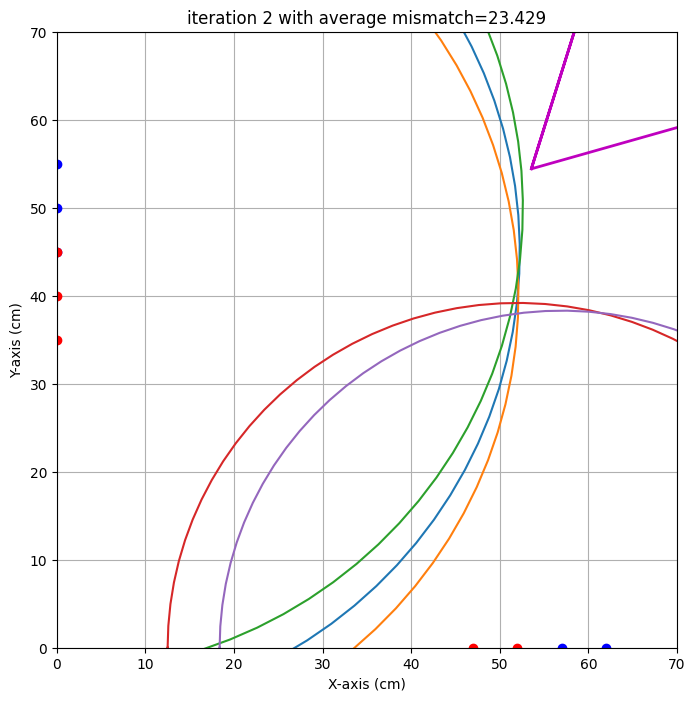

end iteration 2 with average mismatch=23.429


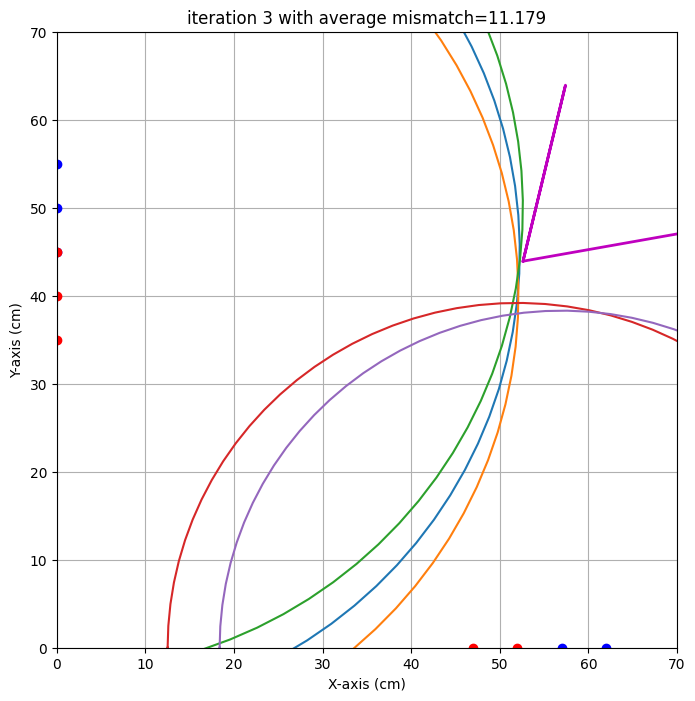

end iteration 3 with average mismatch=11.179


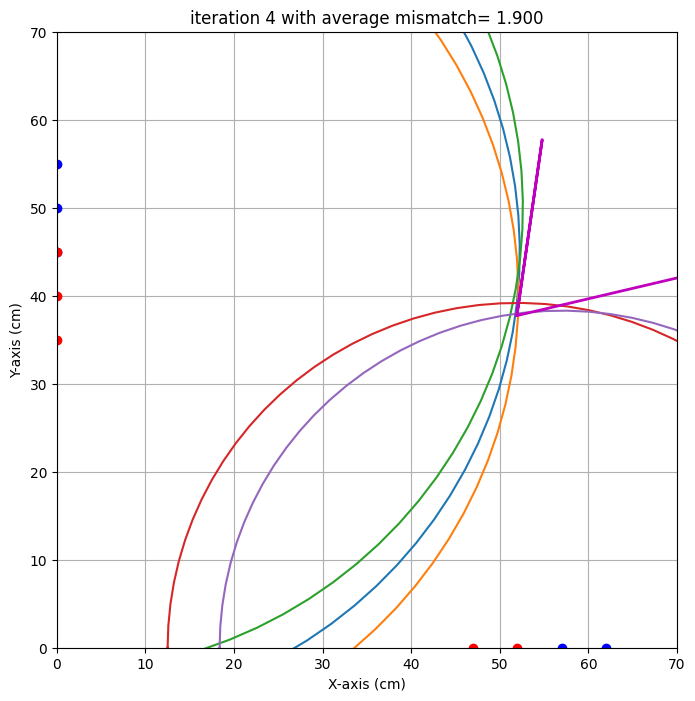

end iteration 4 with average mismatch= 1.900


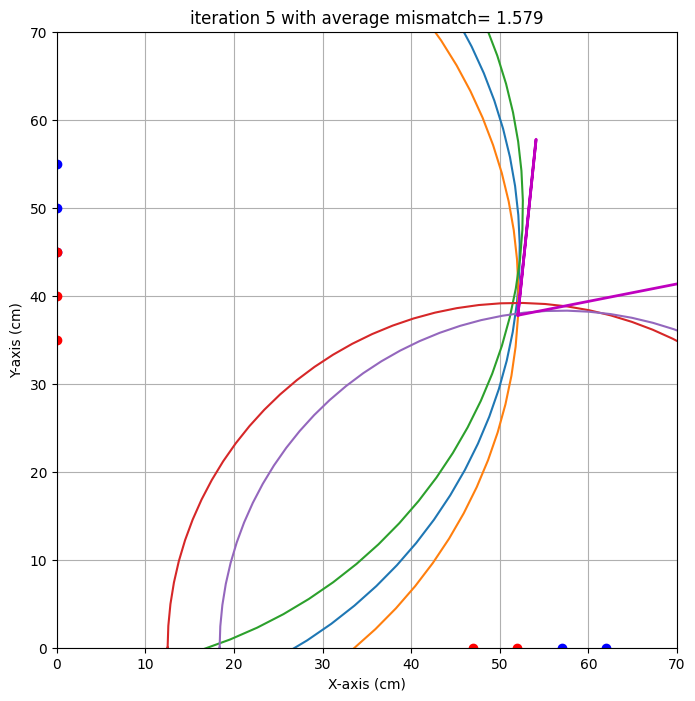

end iteration 5 with average mismatch= 1.579


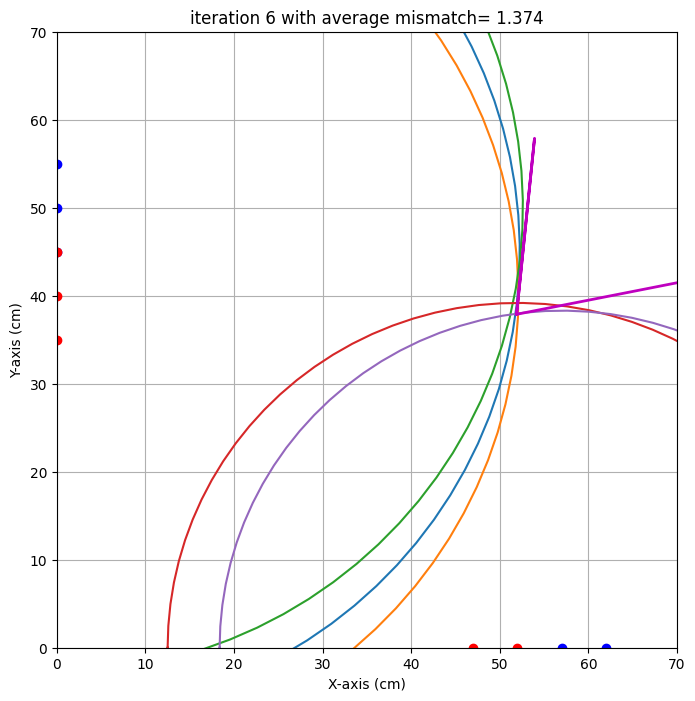

end iteration 6 with average mismatch= 1.374


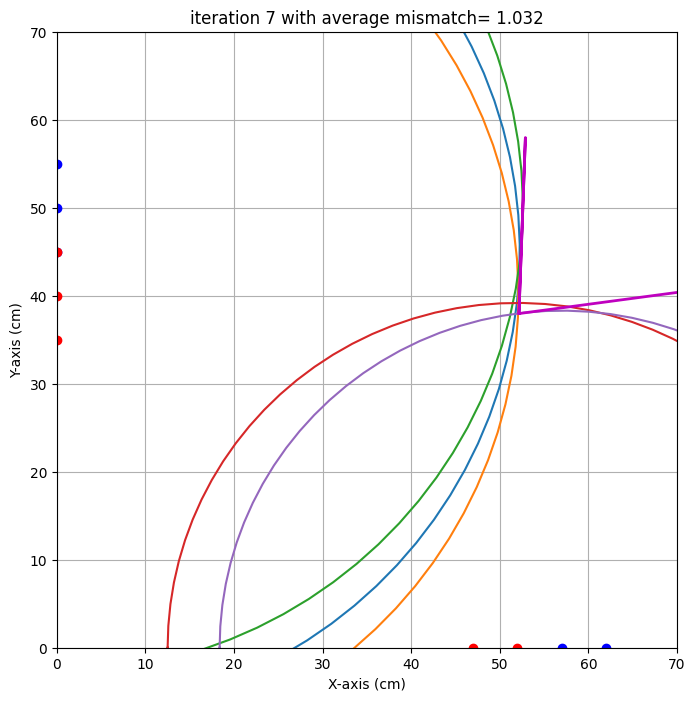

end iteration 7 with average mismatch= 1.032
end iteration 8 with average mismatch= 0.939


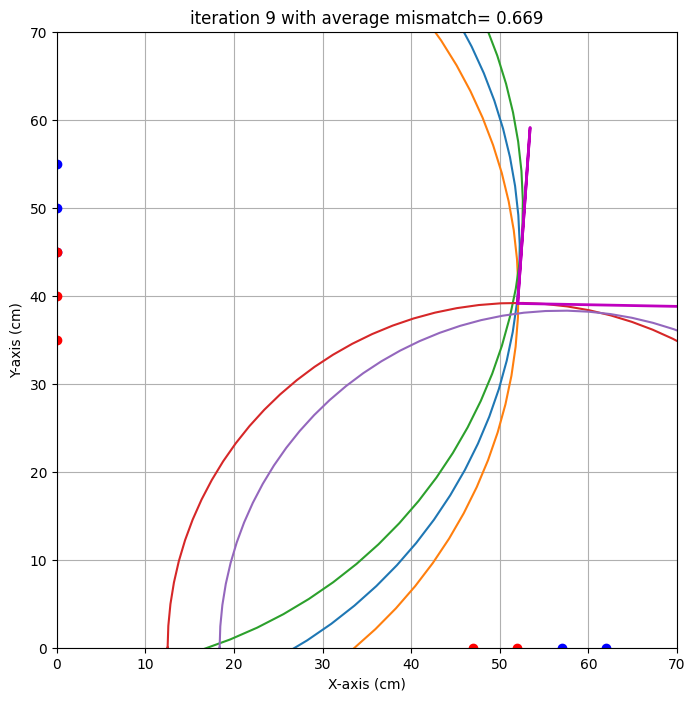

end iteration 9 with average mismatch= 0.669
end iteration 10 with average mismatch= 0.610
end iteration 11 with average mismatch= 0.592


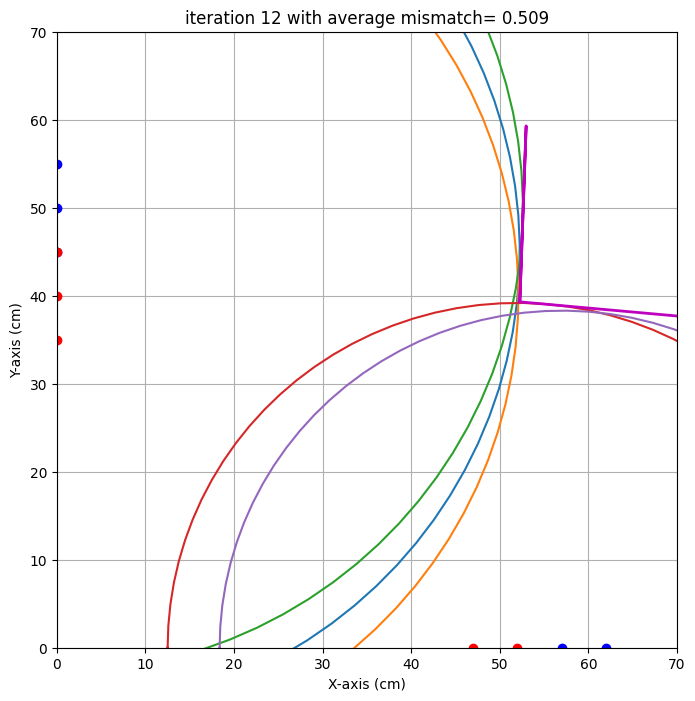

end iteration 12 with average mismatch= 0.509
end iteration 13 with average mismatch= 0.507
end iteration 14 with average mismatch= 0.506
end iteration 15 with average mismatch= 0.494


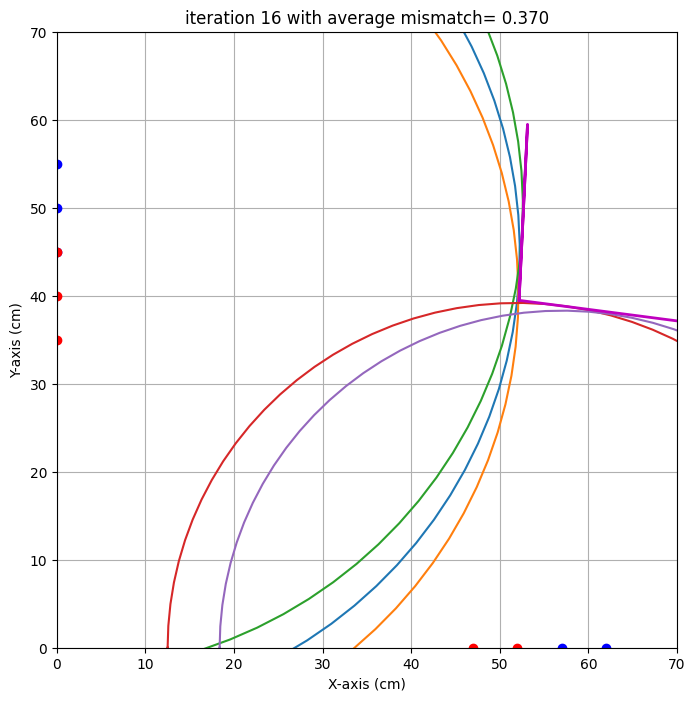

end iteration 16 with average mismatch= 0.370
end iteration 17 with average mismatch= 0.357
end iteration 18 with average mismatch= 0.356
end iteration 19 with average mismatch= 0.356
end iteration 20 with average mismatch= 0.356
end iteration 21 with average mismatch= 0.356
end iteration 22 with average mismatch= 0.356
end iteration 23 with average mismatch= 0.356
end iteration 24 with average mismatch= 0.356
end iteration 25 with average mismatch= 0.356
end iteration 26 with average mismatch= 0.356
end iteration 27 with average mismatch= 0.356
end iteration 28 with average mismatch= 0.356
end iteration 29 with average mismatch= 0.356
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.356
###############################################################################
end of iteration  30
Best alpha=  -7.46 with uncertainty=   7.15
Best beta =   2.73 with uncertainty=   4.33
Best x0   = 

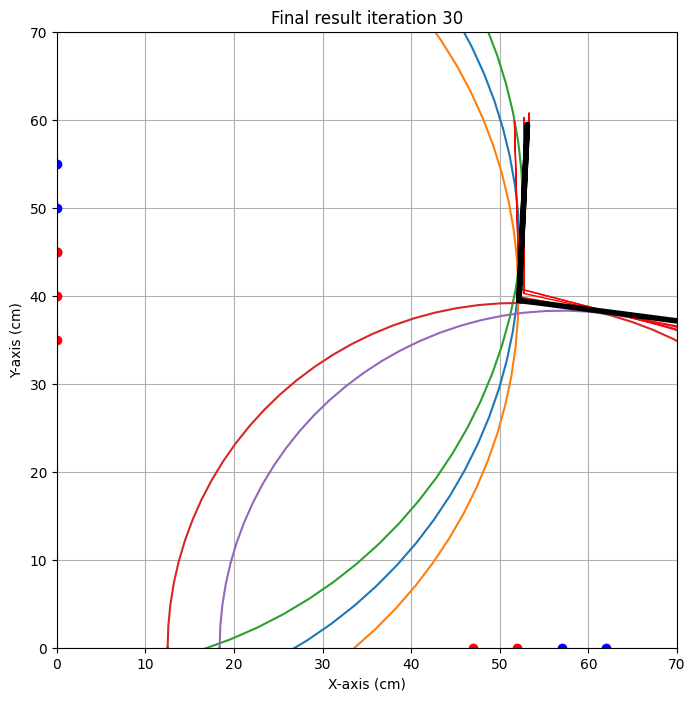

{'alpha': np.float64(-7.459937854196039), 'alpha_eps': np.float64(7.15462991656915), 'beta': np.float64(2.7260700548607857), 'beta_eps': np.float64(4.333267611594498), 'x0': np.float64(52.1671335828031), 'x0_eps': np.float64(0.548504557063545), 'y0': np.float64(39.47254851353724), 'y0_eps': np.float64(1.2954155915184131)}


In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

wout 
x0 target is : 52.0. Gevonden waarde: 52.3 cm met een standaardafwijking van 1.1 cm 
y0 target is : 37.0. Gevonden waarde: 38.1 cm met een standaardafwijking van 0.5 cm 
alpha target is : 0.0. Gevonden waarde: 4.0 graden met een standaardafwijking van 6.9 graad 
beta target is : 25.0. Gevonden waarde: -0.2 graden met een standaardafwijking van 7.0 graad 

isha 
x0 target is : 52.0. Gevonden waarde: 52.2 cm met een standaardafwijking van 0.5 cm 
y0 target is : 37.0. Gevonden waarde: 39.5 cm met een standaardafwijking van 1.3 cm 
alpha target is : 0.0. Gevonden waarde: -7.5 graden met een standaardafwijking van 7.2 graad 
beta target is : 25.0. Gevonden waarde: 2.7 graden met een standaardafwijking van 4.3 graad 



## Opdracht 8: Iteratie1+.14:40.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](eessteiter.jpeg)
Figuur: ![Alt](tweedeiter.jpeg)
Figuur: ![Alt](derdeiter.jpeg)
Figuur: ![Alt](4iter.jpeg)

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  20   0  30   0  70.67
1  30   0  40   0  70.70
2  40   0  50   0  71.20
3   0  30   0  40  51.50
4   0  40   0  50  51.90
5   0  50   0  60  54.50


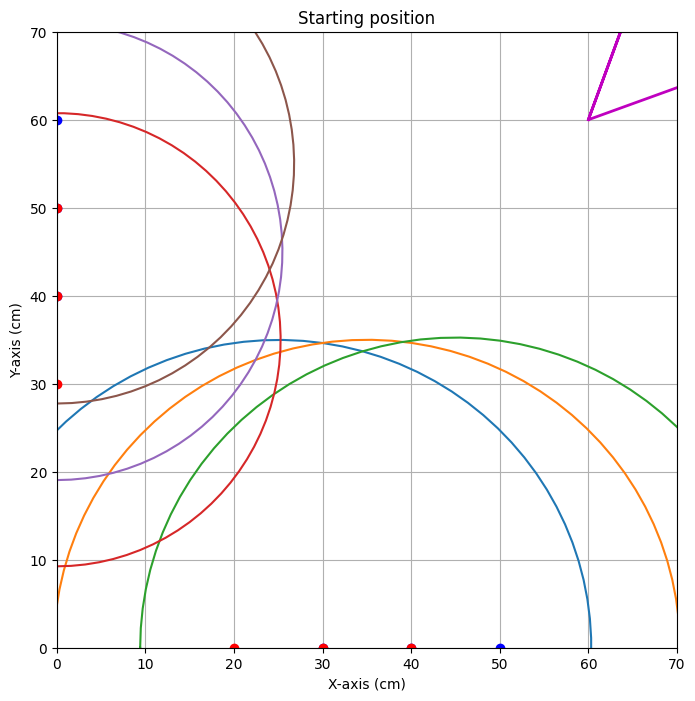


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=72.740


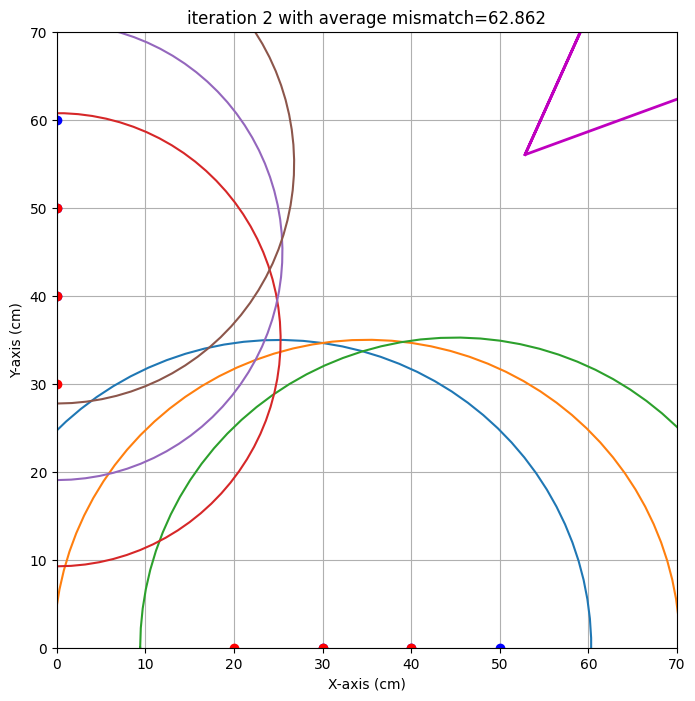

end iteration 2 with average mismatch=62.862


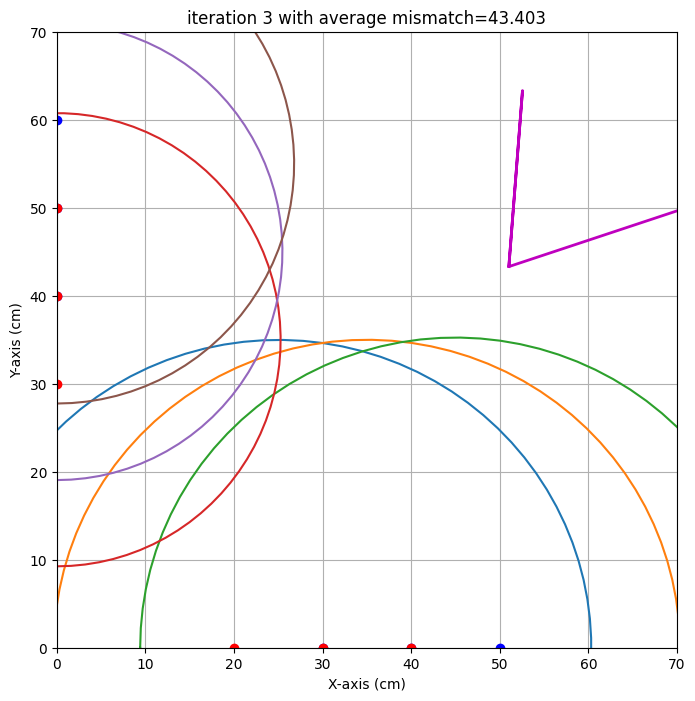

end iteration 3 with average mismatch=43.403


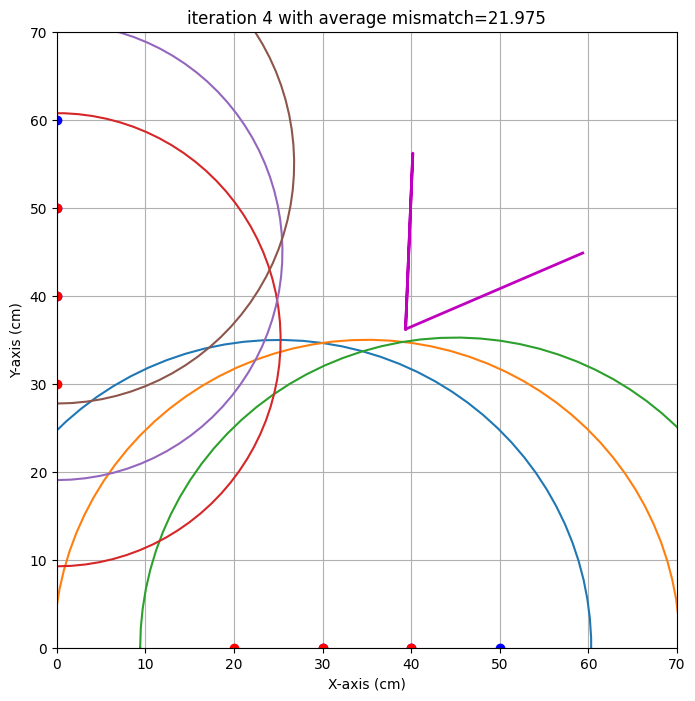

end iteration 4 with average mismatch=21.975


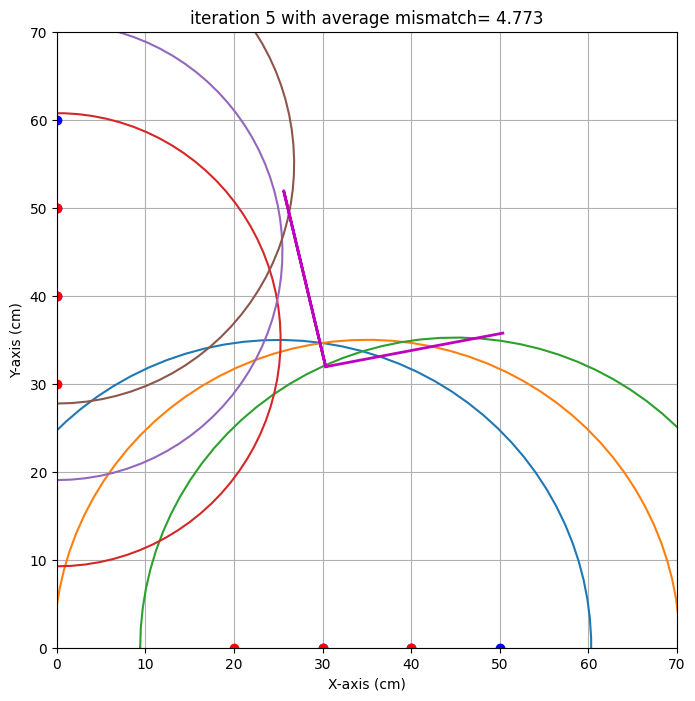

end iteration 5 with average mismatch= 4.773


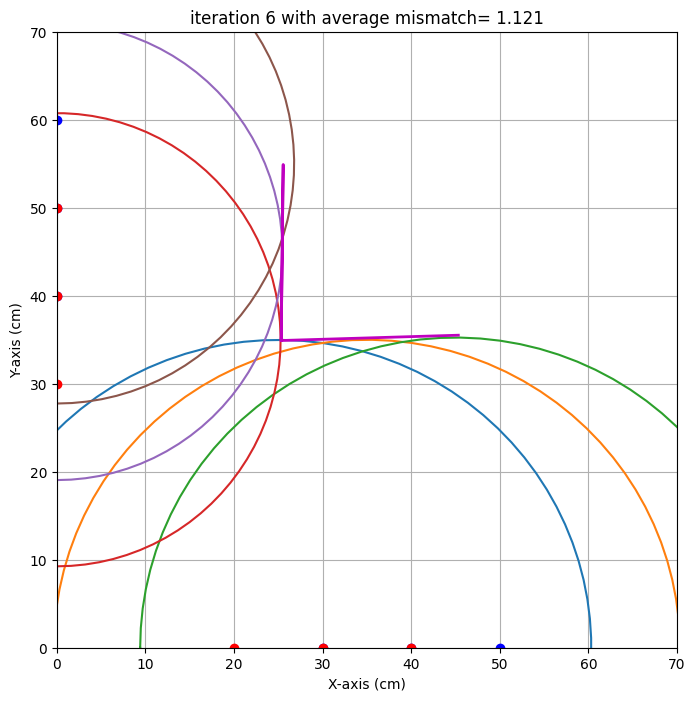

end iteration 6 with average mismatch= 1.121
end iteration 7 with average mismatch= 1.105
end iteration 8 with average mismatch= 1.073
end iteration 9 with average mismatch= 1.073


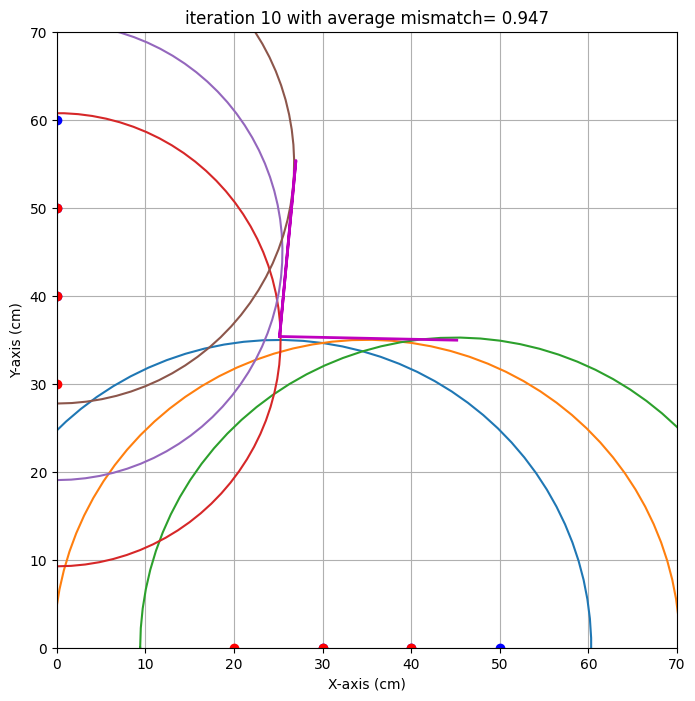

end iteration 10 with average mismatch= 0.947
end iteration 11 with average mismatch= 0.938
end iteration 12 with average mismatch= 0.931
end iteration 13 with average mismatch= 0.930
end iteration 14 with average mismatch= 0.930
end iteration 15 with average mismatch= 0.930


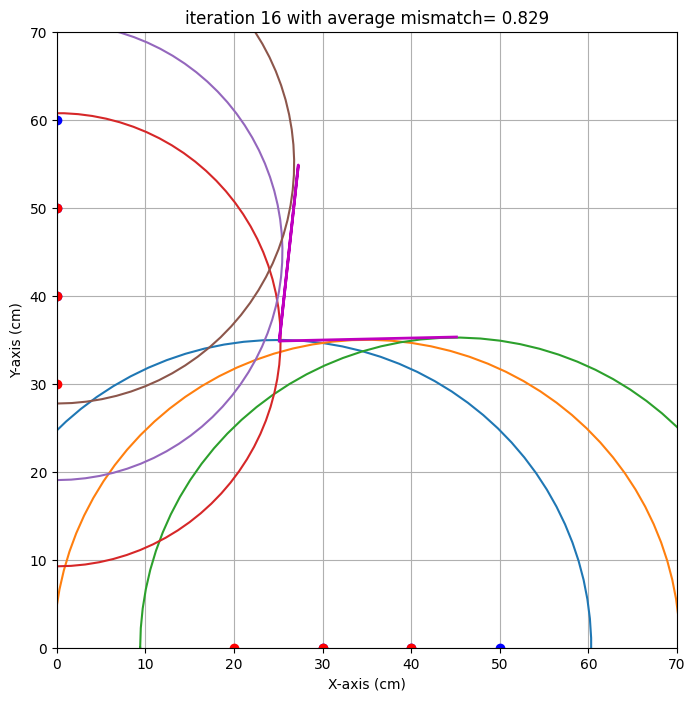

end iteration 16 with average mismatch= 0.829
end iteration 17 with average mismatch= 0.821
end iteration 18 with average mismatch= 0.784
end iteration 19 with average mismatch= 0.784
end iteration 20 with average mismatch= 0.784
end iteration 21 with average mismatch= 0.763
end iteration 22 with average mismatch= 0.760
end iteration 23 with average mismatch= 0.759
end iteration 24 with average mismatch= 0.759
end iteration 25 with average mismatch= 0.759
end iteration 26 with average mismatch= 0.759
end iteration 27 with average mismatch= 0.759
end iteration 28 with average mismatch= 0.759
end iteration 29 with average mismatch= 0.759
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.759
###############################################################################
end of iteration  30
Best alpha=   0.90 with uncertainty=   1.79
Best b

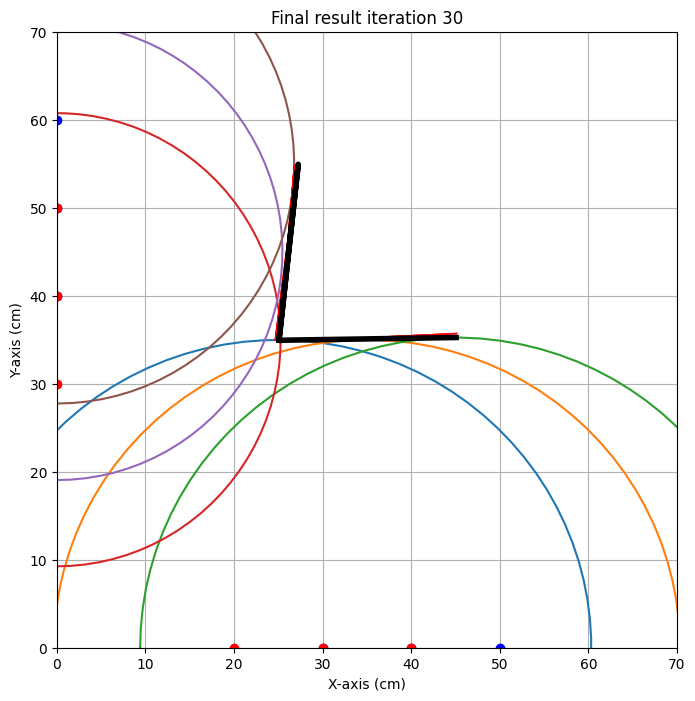

{'alpha': np.float64(0.8997332784657511), 'alpha_eps': np.float64(1.7852647689449581), 'beta': np.float64(6.203248132810924), 'beta_eps': np.float64(1.3529770720226546), 'x0': np.float64(25.07223579387245), 'x0_eps': np.float64(0.4255422476094388), 'y0': np.float64(34.93676655125108), 'y0_eps': np.float64(0.16981295962357024)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  20   0  30   0  42.76
1  30   0  40   0  42.28
2  40   0  50   0  44.00
3   0  20   0  30  47.40
4   0  30   0  40  44.80
5   0  40   0  50  48.60


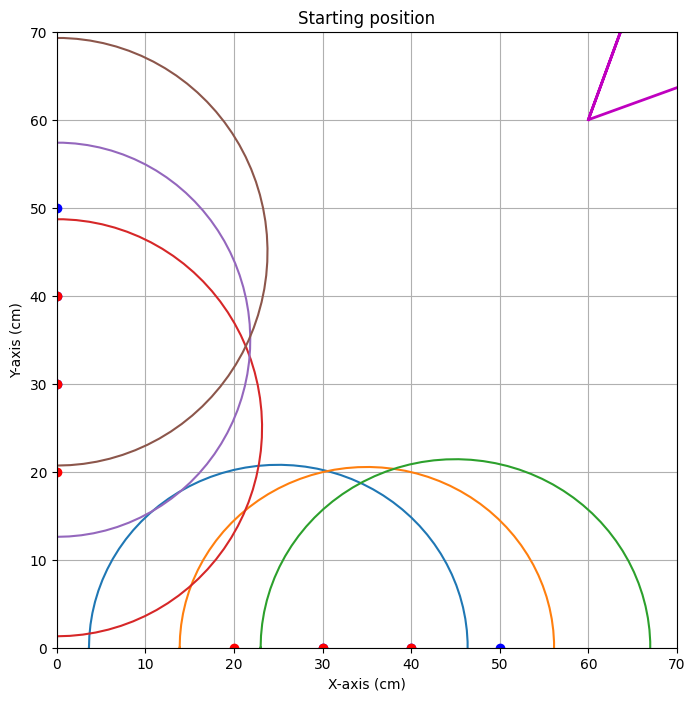


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=93.185


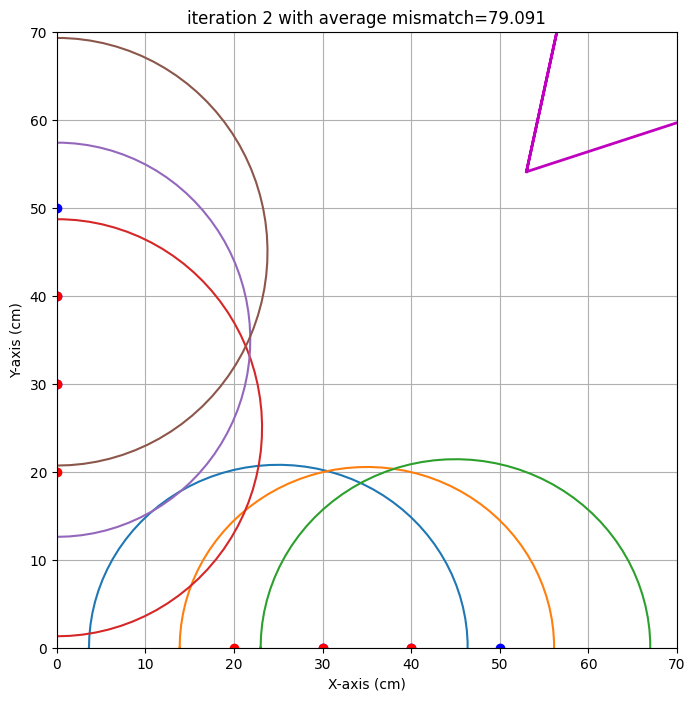

end iteration 2 with average mismatch=79.091


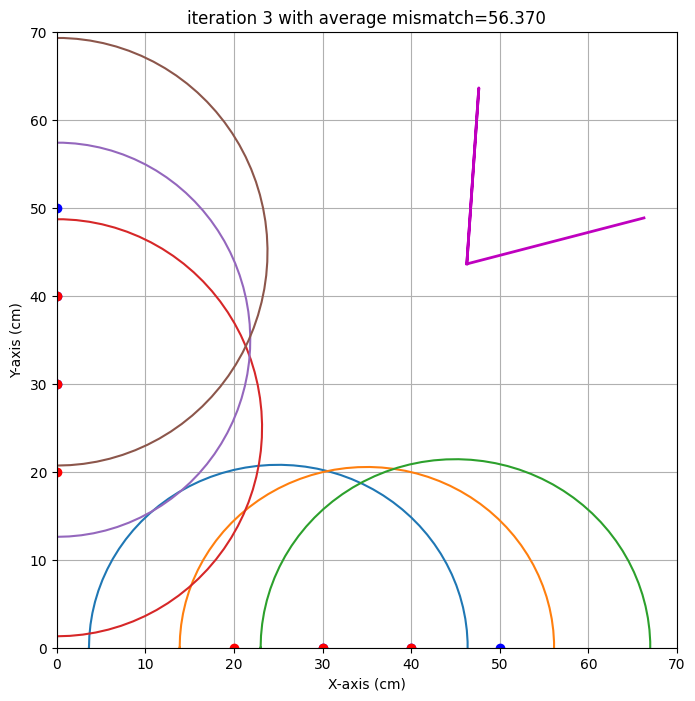

end iteration 3 with average mismatch=56.370


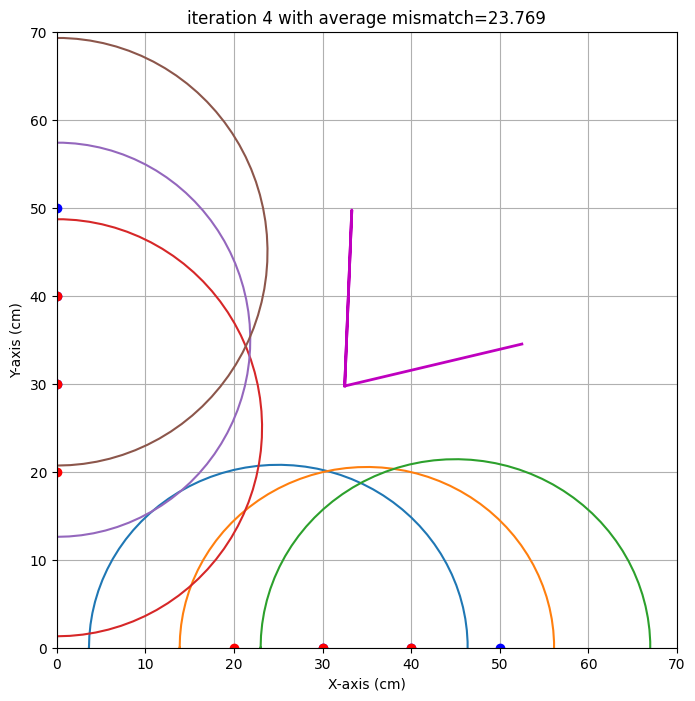

end iteration 4 with average mismatch=23.769


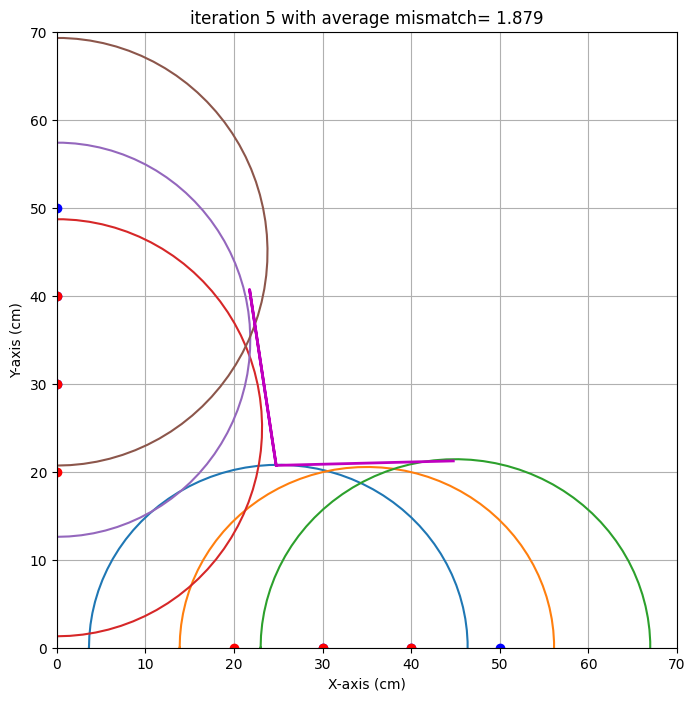

end iteration 5 with average mismatch= 1.879


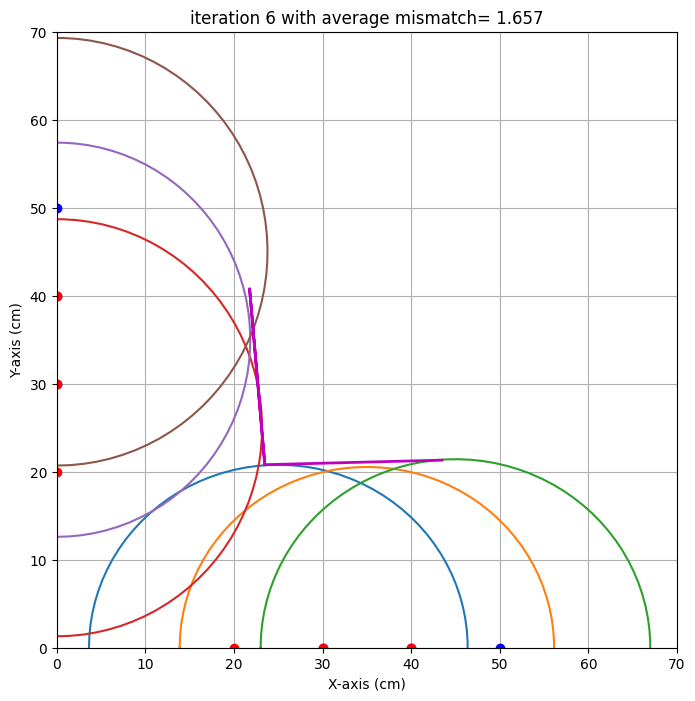

end iteration 6 with average mismatch= 1.657
end iteration 7 with average mismatch= 1.541
end iteration 8 with average mismatch= 1.538
end iteration 9 with average mismatch= 1.537
end iteration 10 with average mismatch= 1.536
end iteration 11 with average mismatch= 1.536
end iteration 12 with average mismatch= 1.536
end iteration 13 with average mismatch= 1.536
end iteration 14 with average mismatch= 1.525
end iteration 15 with average mismatch= 1.460
end iteration 16 with average mismatch= 1.411
end iteration 17 with average mismatch= 1.388
end iteration 18 with average mismatch= 1.372
end iteration 19 with average mismatch= 1.372
end iteration 20 with average mismatch= 1.372
end iteration 21 with average mismatch= 1.372
end iteration 22 with average mismatch= 1.372
end iteration 23 with average mismatch= 1.372
end iteration 24 with average mismatch= 1.372
end iteration 25 with average mismatch= 1.372
end iteration 26 with average mismatch= 1.372
end iteration 27 with average mismatch

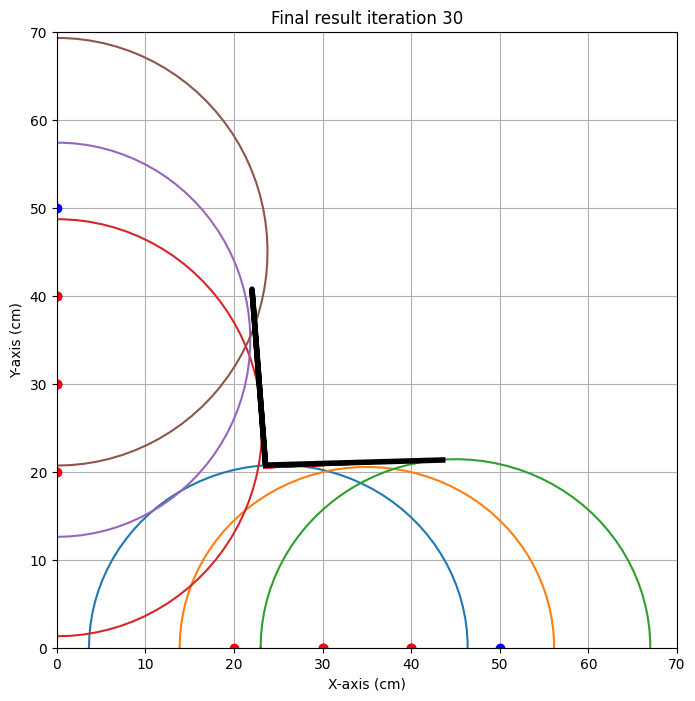

{'alpha': np.float64(1.6730068946115522), 'alpha_eps': np.float64(0.7166793296111591), 'beta': np.float64(-4.38586638710741), 'beta_eps': np.float64(1.083634873351552), 'x0': np.float64(23.55758574987821), 'x0_eps': np.float64(0.1628018517837866), 'y0': np.float64(20.748378365421104), 'y0_eps': np.float64(0.30901876205122747)}
locatie 3
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  30   0  40  91.2
1   0  40   0  50  90.6
2   0  50   0  60  93.0
3  50   0  60   0  79.6
4  55   0  65   0  82.5
5  60   0  70   0  84.3


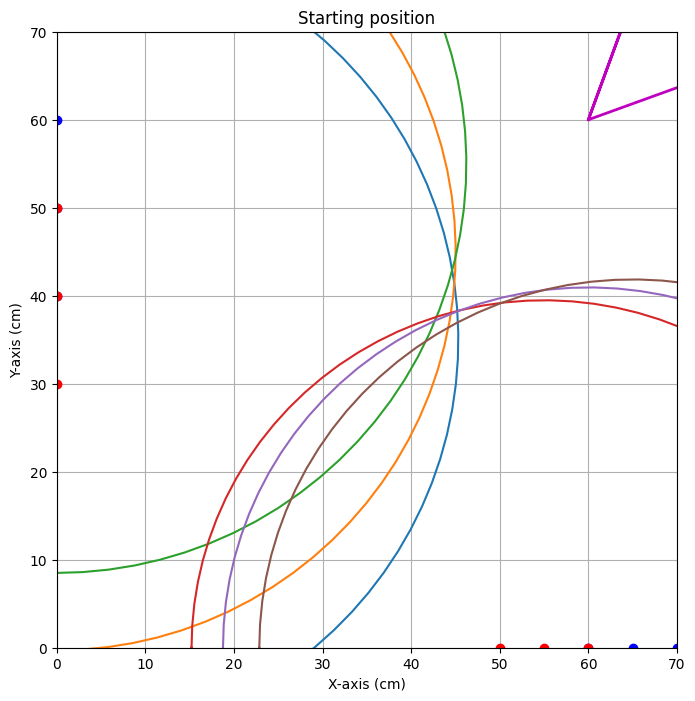


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=42.352


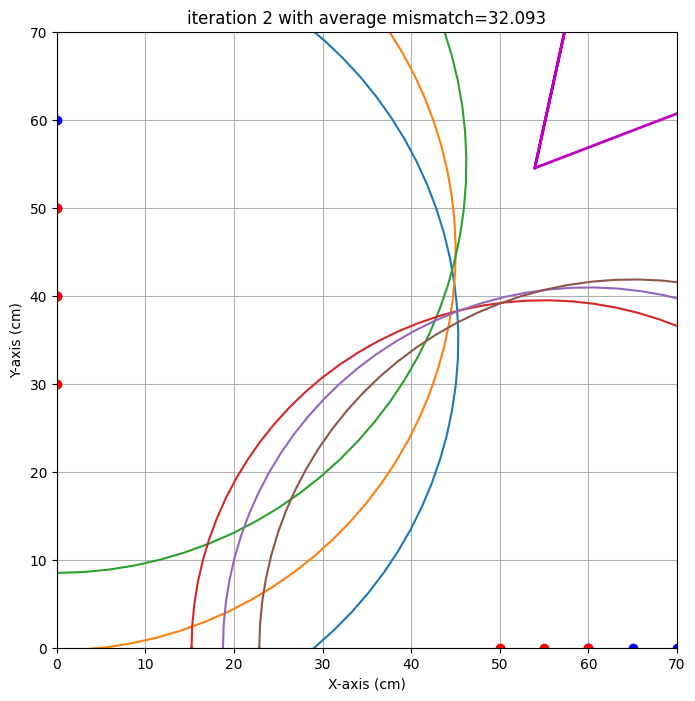

end iteration 2 with average mismatch=32.093


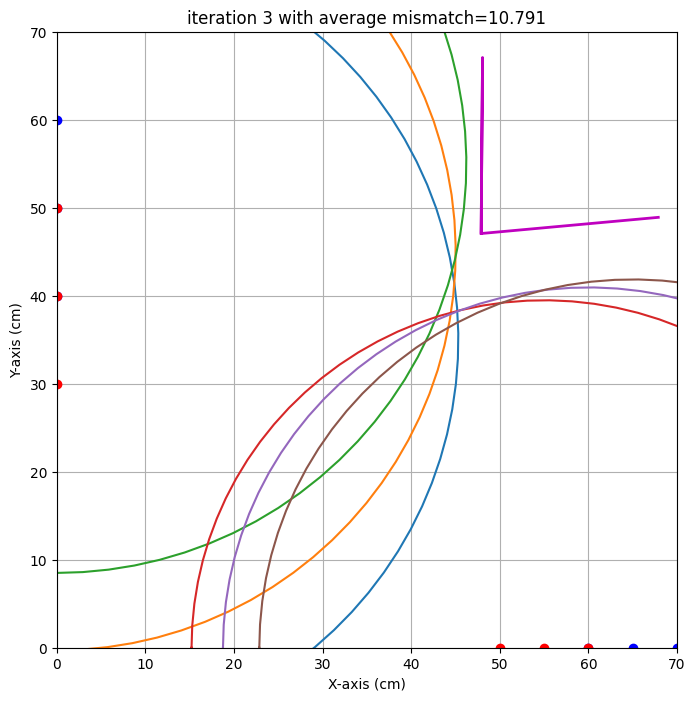

end iteration 3 with average mismatch=10.791


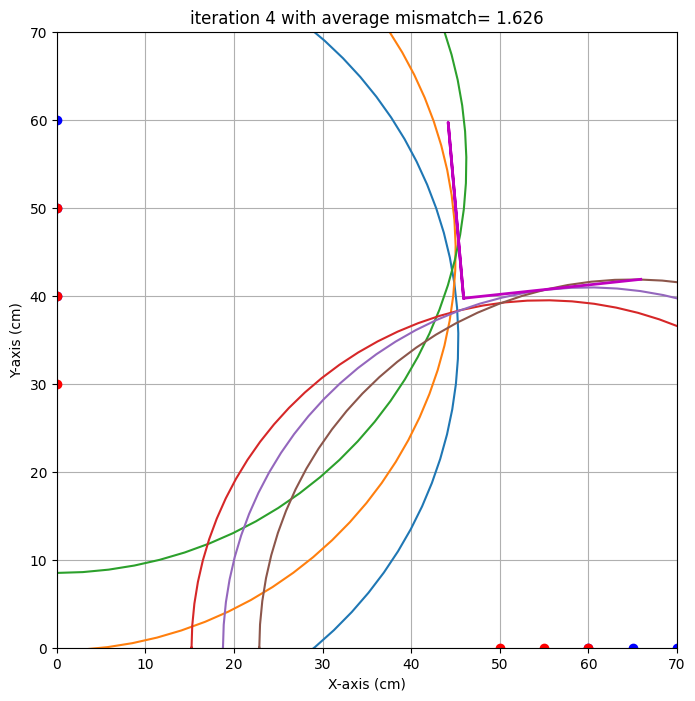

end iteration 4 with average mismatch= 1.626


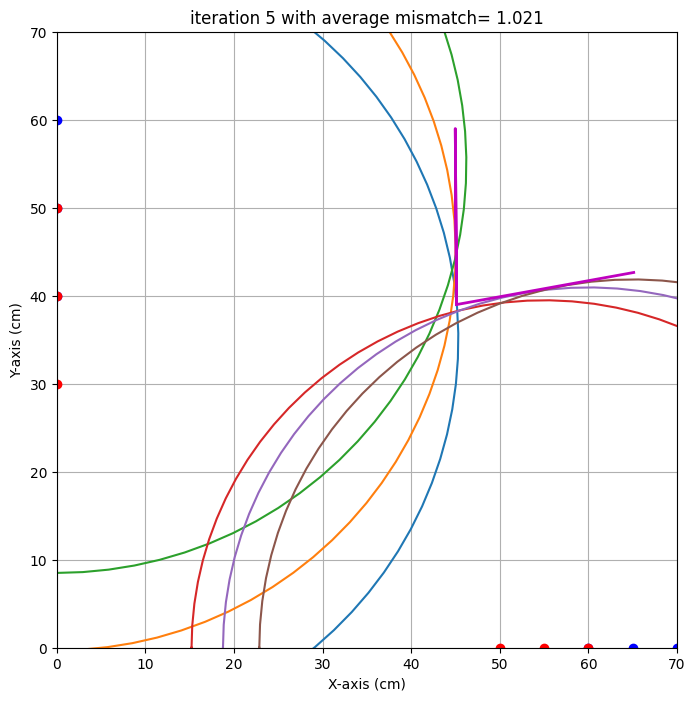

end iteration 5 with average mismatch= 1.021
end iteration 6 with average mismatch= 0.963
end iteration 7 with average mismatch= 0.952
end iteration 8 with average mismatch= 0.926
end iteration 9 with average mismatch= 0.838
end iteration 10 with average mismatch= 0.813
end iteration 11 with average mismatch= 0.807
end iteration 12 with average mismatch= 0.806
end iteration 13 with average mismatch= 0.806
end iteration 14 with average mismatch= 0.805
end iteration 15 with average mismatch= 0.805
end iteration 16 with average mismatch= 0.805
end iteration 17 with average mismatch= 0.805
end iteration 18 with average mismatch= 0.805
end iteration 19 with average mismatch= 0.805
end iteration 20 with average mismatch= 0.805
end iteration 21 with average mismatch= 0.805
end iteration 22 with average mismatch= 0.805
end iteration 23 with average mismatch= 0.805
end iteration 24 with average mismatch= 0.805
end iteration 25 with average mismatch= 0.805
end iteration 26 with average mismatch=

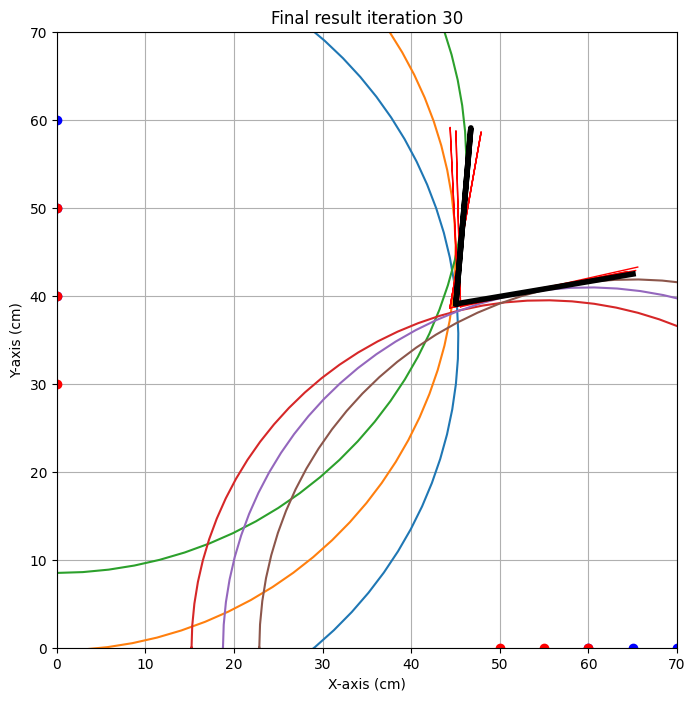

{'alpha': np.float64(9.634814748145837), 'alpha_eps': np.float64(3.07511011307861), 'beta': np.float64(4.836882744306237), 'beta_eps': np.float64(7.52297444520986), 'x0': np.float64(45.044512525751834), 'x0_eps': np.float64(0.671912724477572), 'y0': np.float64(39.07239715286551), 'y0_eps': np.float64(0.4612211505604975)}
locatie 1 
x0 target is : 34.6. Gevonden waarde: 25.1 cm met een standaardafwijking van 0.4 cm 
y0 target is : 25.0. Gevonden waarde: 34.9 cm met een standaardafwijking van 0.2 cm 
alpha target is : 0.0. Gevonden waarde: 0.9 graden met een standaardafwijking van 1.8 graad 
beta target is : 4.0. Gevonden waarde: 6.2 graden met een standaardafwijking van 1.4 graad 

locatie 2 
x0 target is : 20.0. Gevonden waarde: 23.6 cm met een standaardafwijking van 0.2 cm 
y0 target is : 25.0. Gevonden waarde: 20.7 cm met een standaardafwijking van 0.3 cm 
alpha target is : 0.0. Gevonden waarde: 1.7 graden met een standaardafwijking van 0.7 graad 
beta target is : 10.0. Gevonden waar

In [10]:
# Voeg hier je meetgegevens van deze iteratie in:
#________________locatie 1 is iteratie 1 locatie 2 is iteratie 2 .etc_______________________


# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':34.6,#zelf aanvullen,
                    'y0':25, #zelf aanvullen,
                    'alpha' :0, #zelf aanvullen,
                    'beta' :4, #zelf aanvullen}, 
},
           'locatie 2':{'x0':20,#zelf aanvullen,
                    'y0':25, #zelf aanvullen,
                    'alpha' :0, #zelf aanvullen,
                    'beta' :10, #zelf aanvullen
},
            'locatie 3':{
                    'x0': 44,  # zelf aanvullen,
                    'y0': 37,  # zelf aanvullen,
                    'alpha' :10,  # zelf aanvullen,
                    'beta' :11,  # zelf aanvullen
            }}
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    [20,0,30,0,70.67],
    [30,0,40,0,70.7],
    [40,0,50,0,71.2],
    #[50,0,60,0,76.6],
    #[0,20,0,30,0],
    [0,30,0,40,51.5],
    [0,40,0,50,51.9],
    [0,50,0,60,54.5],
    
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [20,0,30,0,42.76],
    [30,0,40,0,42.28],
    [40,0,50,0,44.0],
    #[50,0,60,0,51.4],
    [0,20,0,30,47.40],
    [0,30,0,40,44.80],
    [0,40,0,50,48.6]
    #[0,50,0,60,0],
    ]),
       'locatie 3' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,30,0,40,91.2],
    [0,40,0,50,90.6],
    [0,50,0,60,93.0],
    [50,0,60,0,79.6],
    [55,0,65,0,82.5],
    [60,0,70,0,84.3],
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  50  87.57
1   0  50   0  60  89.20
2  50   0  60   0  66.52
3  55   0  65   0  67.06
4  60   0  70   0  68.49


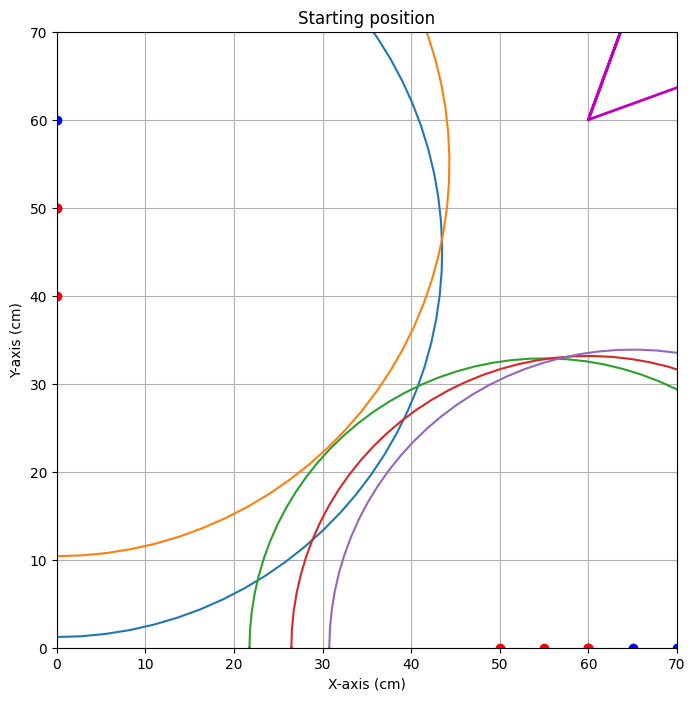


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=52.165


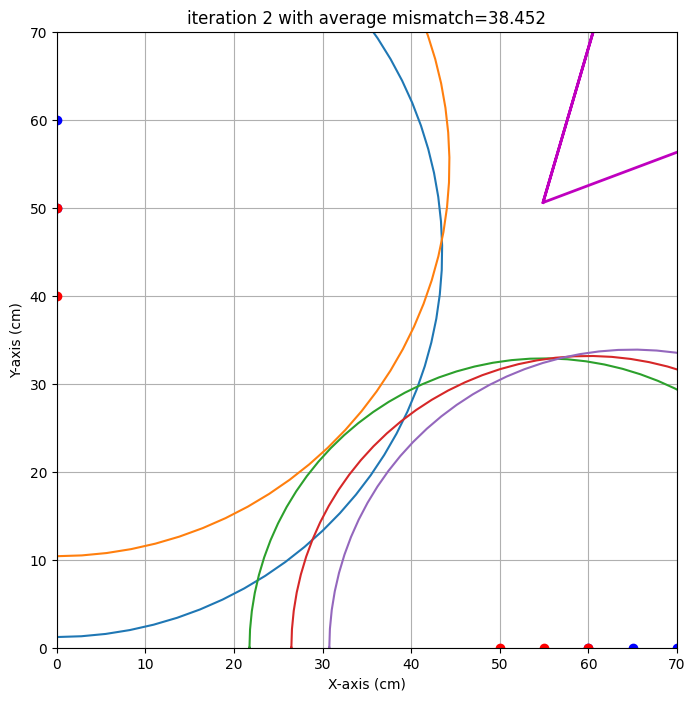

end iteration 2 with average mismatch=38.452


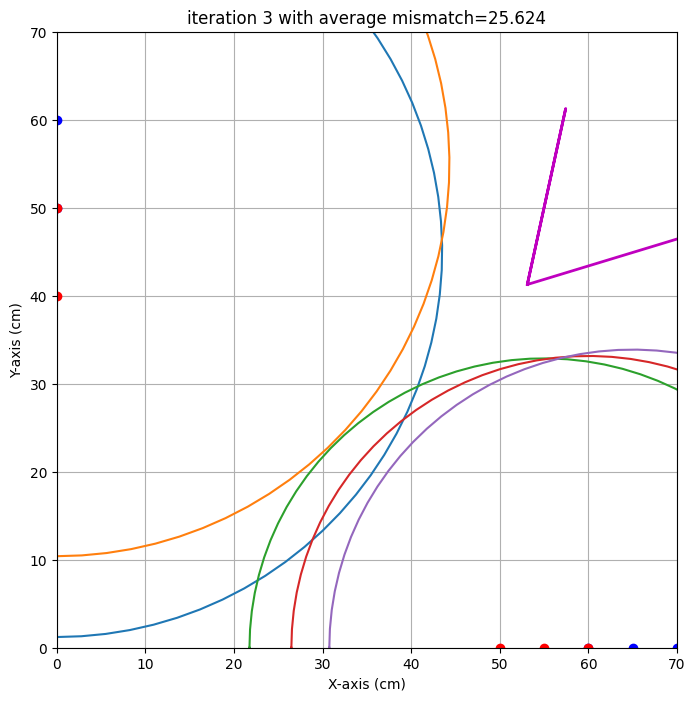

end iteration 3 with average mismatch=25.624


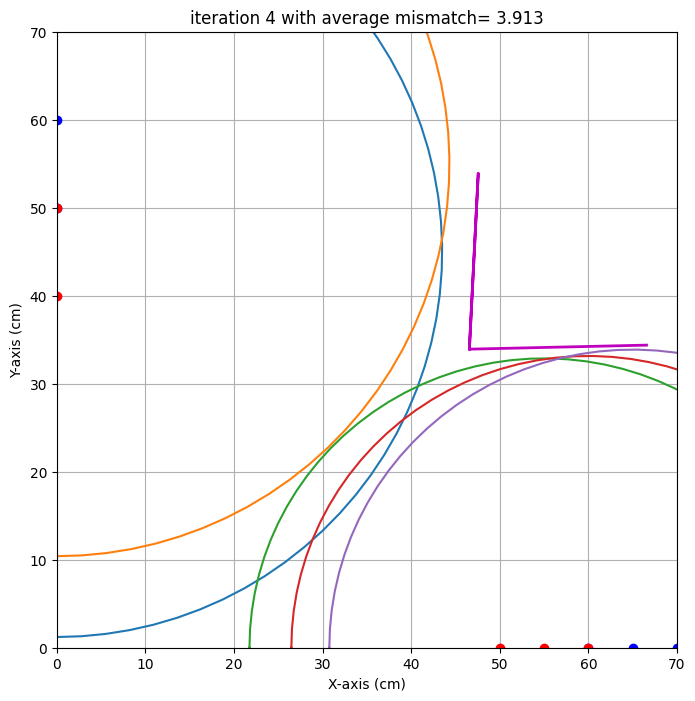

end iteration 4 with average mismatch= 3.913


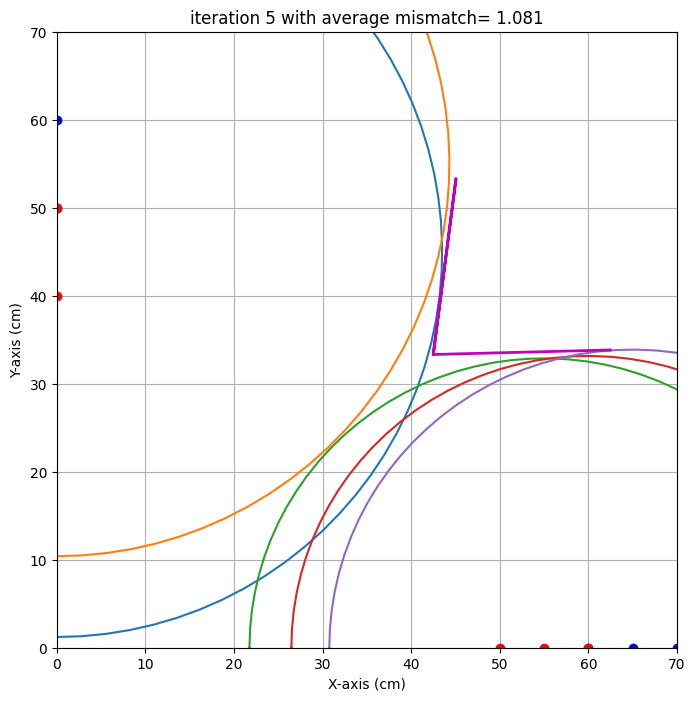

end iteration 5 with average mismatch= 1.081


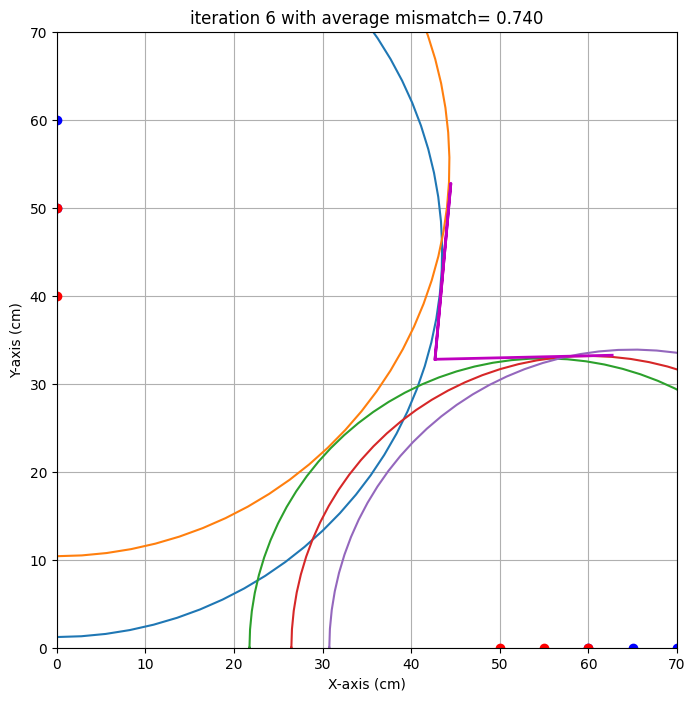

end iteration 6 with average mismatch= 0.740
end iteration 7 with average mismatch= 0.684


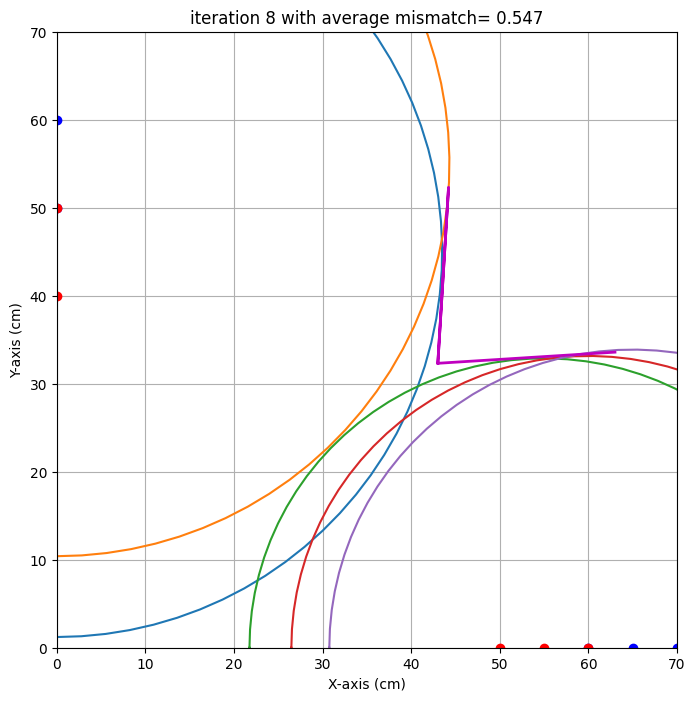

end iteration 8 with average mismatch= 0.547


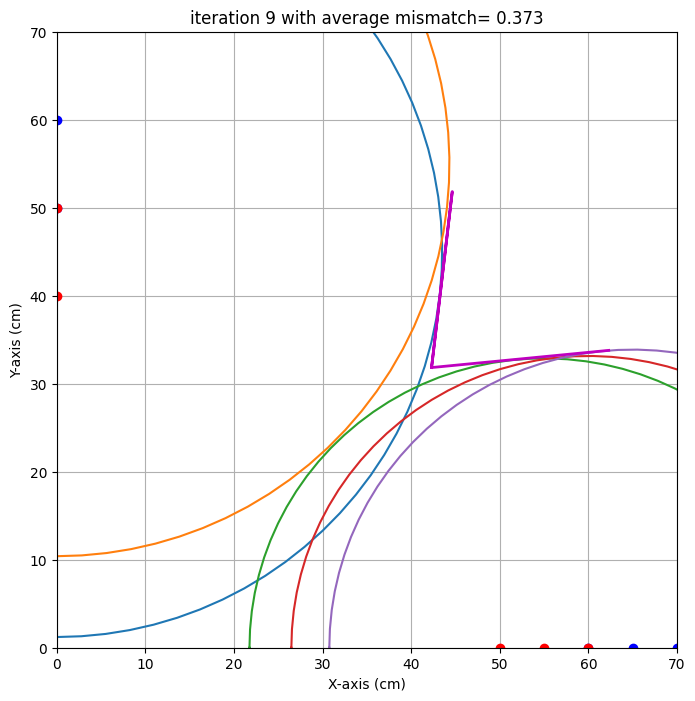

end iteration 9 with average mismatch= 0.373
end iteration 10 with average mismatch= 0.352
end iteration 11 with average mismatch= 0.345
end iteration 12 with average mismatch= 0.345
end iteration 13 with average mismatch= 0.345
end iteration 14 with average mismatch= 0.345
end iteration 15 with average mismatch= 0.345
end iteration 16 with average mismatch= 0.345
end iteration 17 with average mismatch= 0.345
end iteration 18 with average mismatch= 0.345
end iteration 19 with average mismatch= 0.345
end iteration 20 with average mismatch= 0.345
end iteration 21 with average mismatch= 0.345
end iteration 22 with average mismatch= 0.341


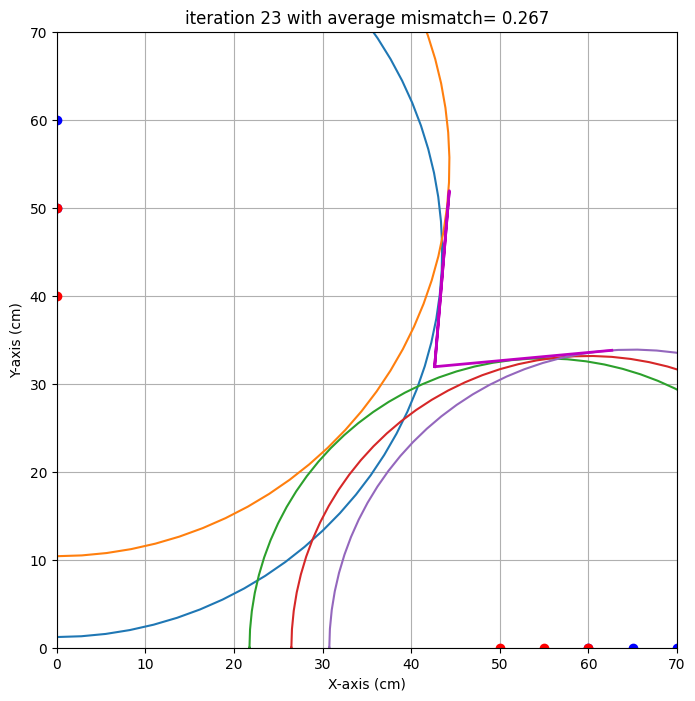

end iteration 23 with average mismatch= 0.267
end iteration 24 with average mismatch= 0.265
end iteration 25 with average mismatch= 0.264
end iteration 26 with average mismatch= 0.264
end iteration 27 with average mismatch= 0.264
end iteration 28 with average mismatch= 0.264
end iteration 29 with average mismatch= 0.264
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.264
###############################################################################
end of iteration  30
Best alpha=   5.32 with uncertainty=   2.92
Best beta =   4.72 with uncertainty=   2.05
Best x0   =  42.64 with uncertainty=   0.47
Best y0   =  31.93 with uncertainty=   0.52
###############################################################################


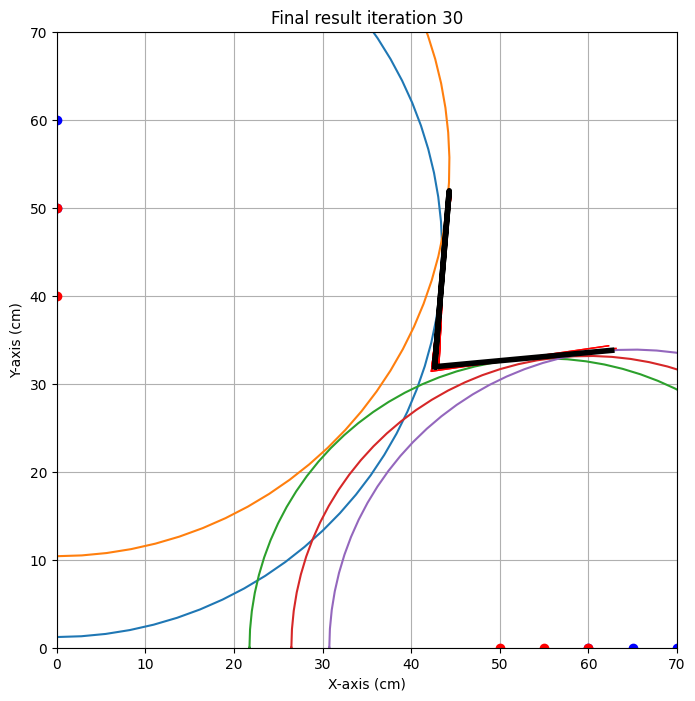

{'alpha': np.float64(5.324073211150632), 'alpha_eps': np.float64(2.9242094653399535), 'beta': np.float64(4.722273113232085), 'beta_eps': np.float64(2.0522304503775275), 'x0': np.float64(42.64328359999365), 'x0_eps': np.float64(0.47302812231919233), 'y0': np.float64(31.92959826048051), 'y0_eps': np.float64(0.5170982422567256)}
test locatie 
x0 target is : 45.4. Gevonden waarde: 42.6 cm met een standaardafwijking van 0.5 cm 
y0 target is : 31.7. Gevonden waarde: 31.9 cm met een standaardafwijking van 0.5 cm 
alpha target is : 5.0. Gevonden waarde: 5.3 graden met een standaardafwijking van 2.9 graad 
beta target is : 5.0. Gevonden waarde: 4.7 graden met een standaardafwijking van 2.1 graad 



In [11]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 45.4,  # zelf aanvullen,
                    'y0': 31.7,  # zelf aanvullen,
                    'alpha' :5,  # zelf aanvullen,
                    'beta' : 5,  # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #
    #[0,30,0,40,91.08], 
    [0,40,0,50,87.57],
    [0,50,0,60,89.2],
    [50,0,60,0,66.52],
    [55,0,65,0,67.06],
    [60,0,70,0,68.49],
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](eessteiter.jpeg)
Figuur: ![Alt](tweedeiter.jpeg)
Figuur: ![Alt](derdeiter.jpeg)
Figuur: ![Alt](4iter.jpeg)

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  20   0  30   0  70.67
1  30   0  40   0  70.70
2  40   0  50   0  71.20
3   0  30   0  40  51.50
4   0  40   0  50  51.90
5   0  50   0  60  54.50


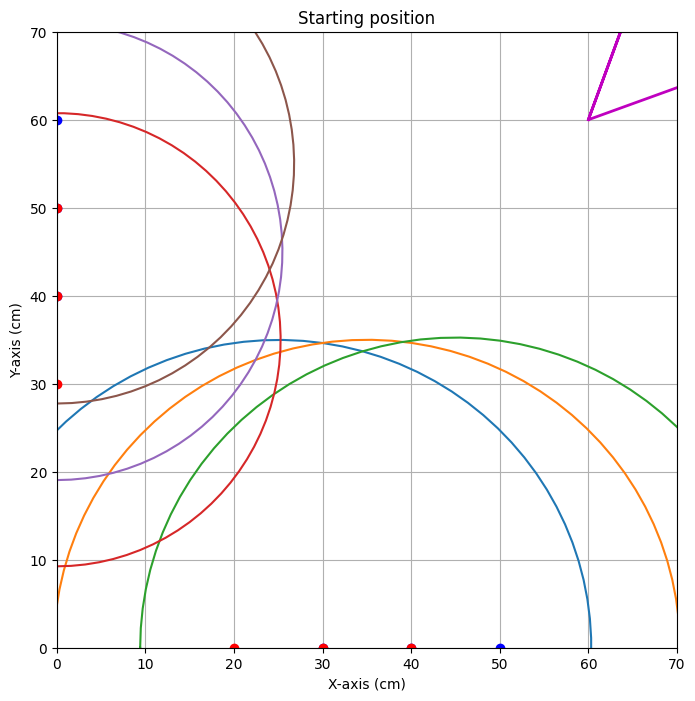


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=72.740


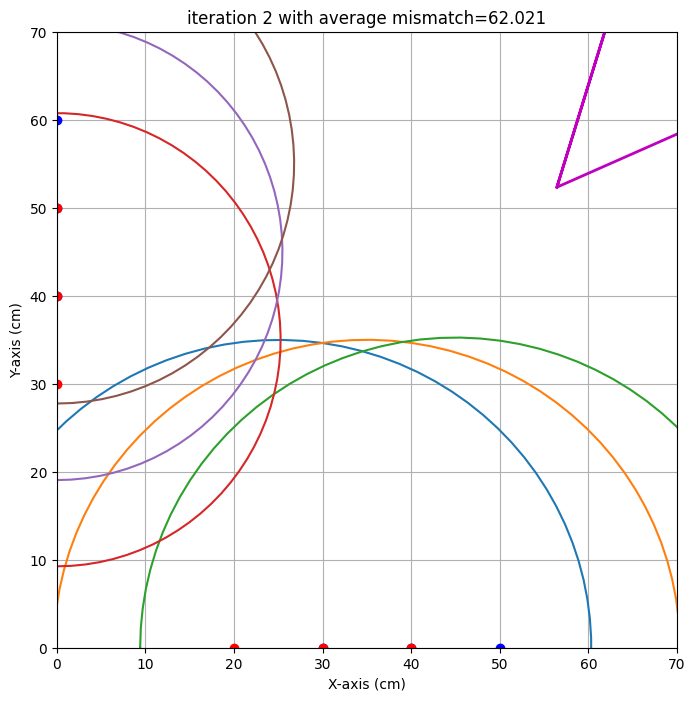

end iteration 2 with average mismatch=62.021


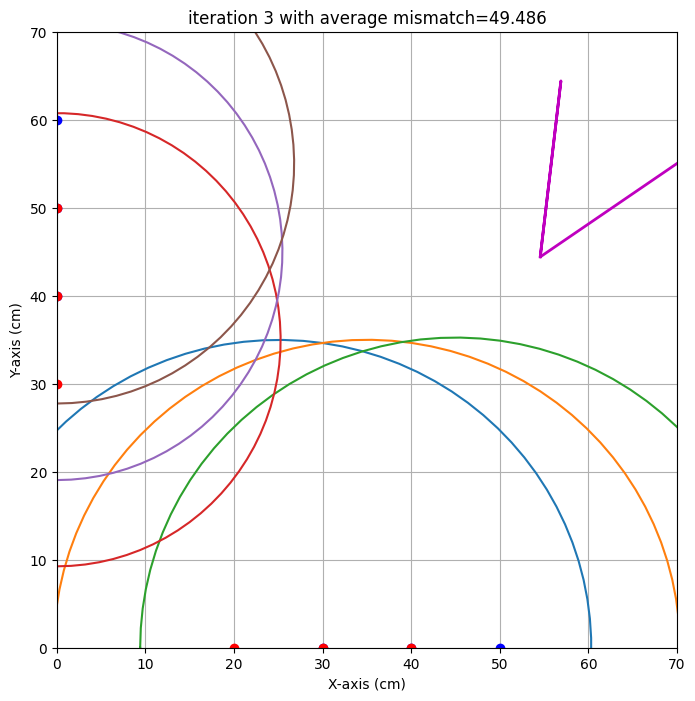

end iteration 3 with average mismatch=49.486


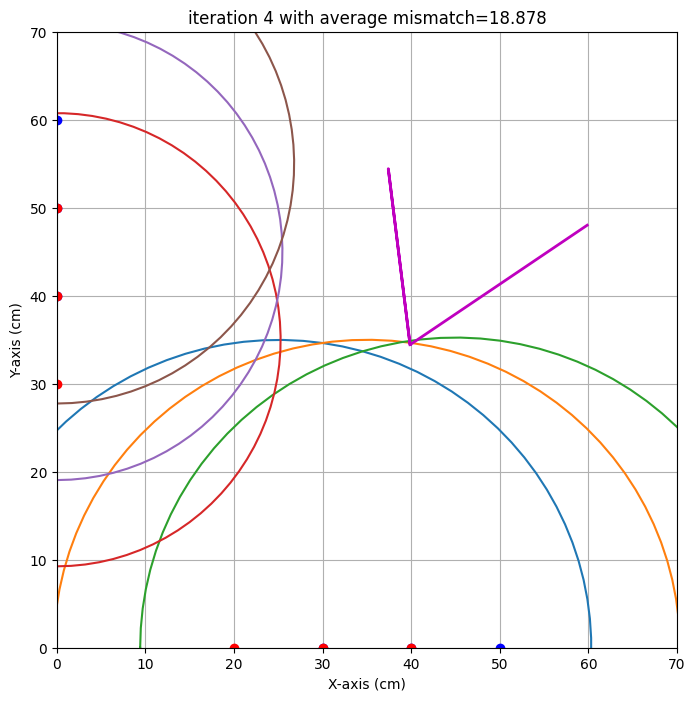

end iteration 4 with average mismatch=18.878


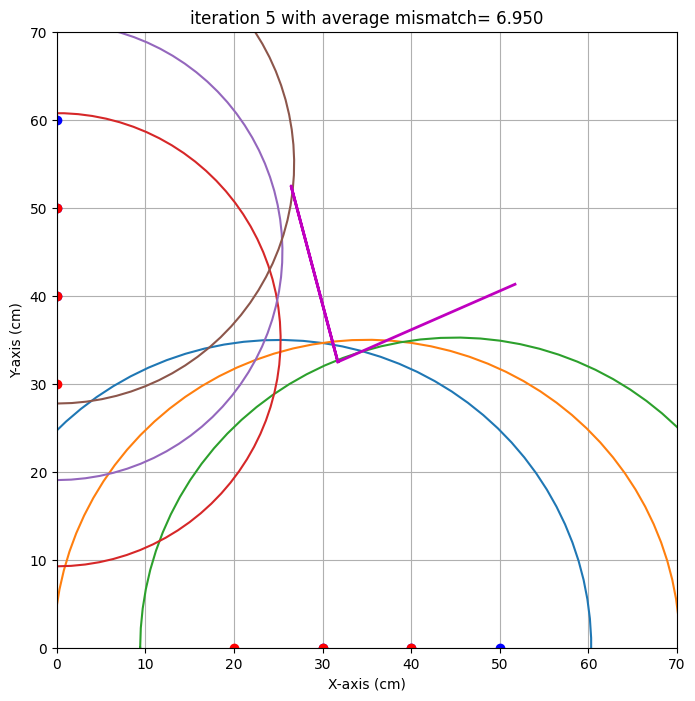

end iteration 5 with average mismatch= 6.950


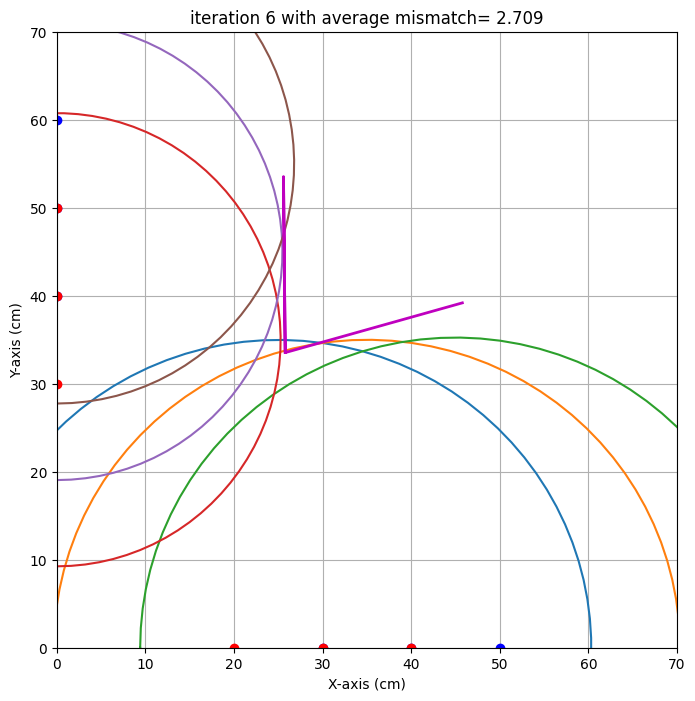

end iteration 6 with average mismatch= 2.709


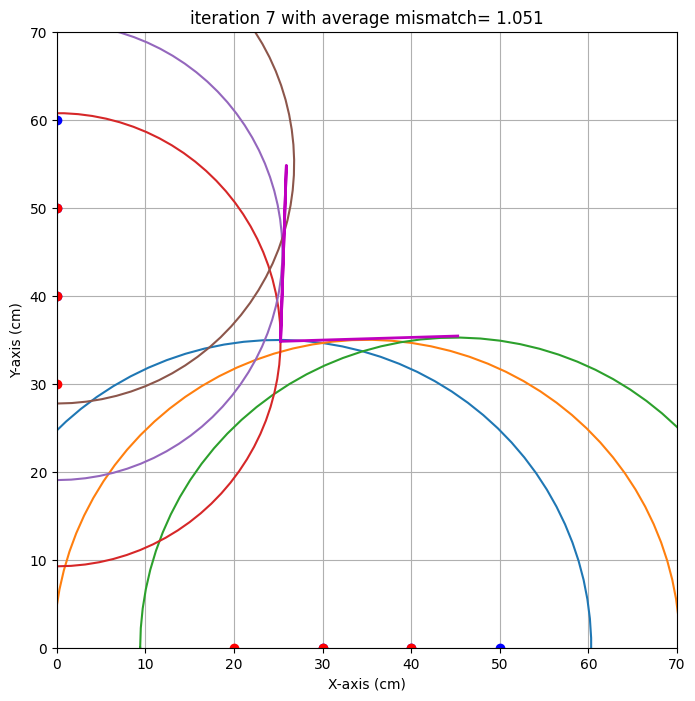

end iteration 7 with average mismatch= 1.051


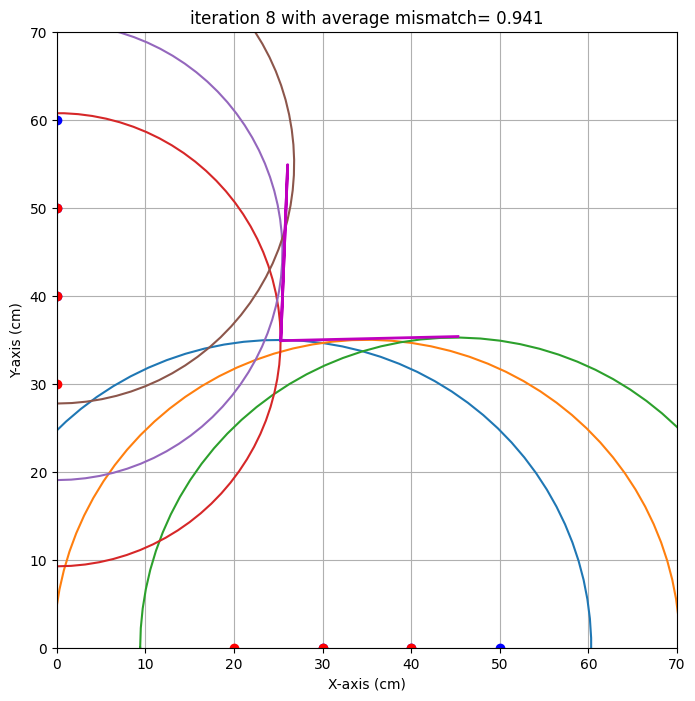

end iteration 8 with average mismatch= 0.941
end iteration 9 with average mismatch= 0.920
end iteration 10 with average mismatch= 0.912


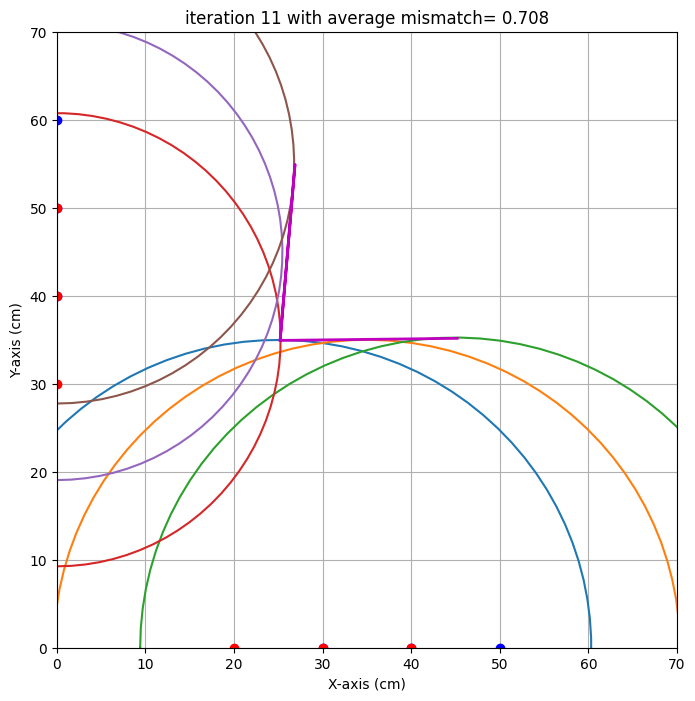

end iteration 11 with average mismatch= 0.708
end iteration 12 with average mismatch= 0.708
end iteration 13 with average mismatch= 0.708
end iteration 14 with average mismatch= 0.708
end iteration 15 with average mismatch= 0.708
end iteration 16 with average mismatch= 0.708
end iteration 17 with average mismatch= 0.708
end iteration 18 with average mismatch= 0.708
end iteration 19 with average mismatch= 0.708
end iteration 20 with average mismatch= 0.708
end iteration 21 with average mismatch= 0.708
end iteration 22 with average mismatch= 0.701
end iteration 23 with average mismatch= 0.677
end iteration 24 with average mismatch= 0.674
end iteration 25 with average mismatch= 0.672
end iteration 26 with average mismatch= 0.669
end iteration 27 with average mismatch= 0.667
end iteration 28 with average mismatch= 0.667
end iteration 29 with average mismatch= 0.667
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 

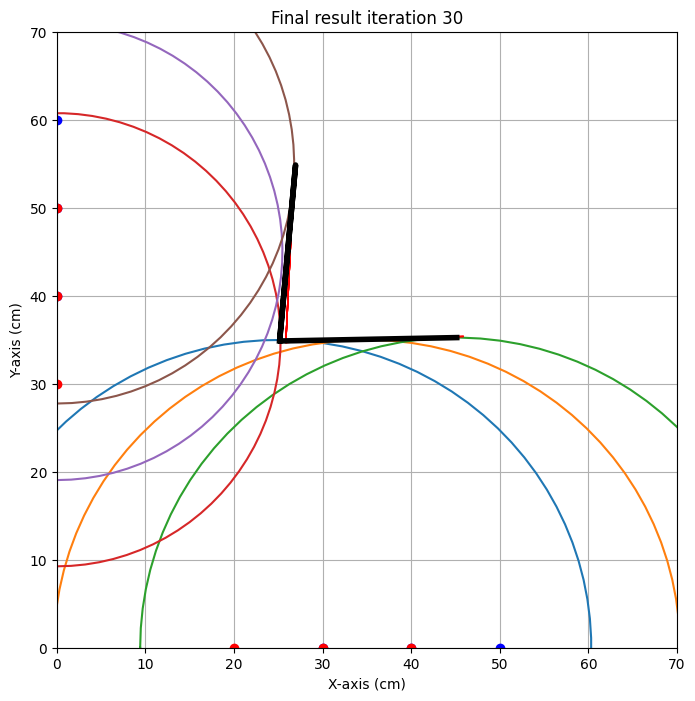

{'alpha': np.float64(1.1116062885887499), 'alpha_eps': np.float64(0.8501287788314285), 'beta': np.float64(5.1523634995557615), 'beta_eps': np.float64(2.390823514367615), 'x0': np.float64(25.1422093415), 'x0_eps': np.float64(0.70514767506263), 'y0': np.float64(34.854307708419924), 'y0_eps': np.float64(0.16520745592990949)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  20   0  30   0  42.76
1  30   0  40   0  42.28
2  40   0  50   0  44.00
3   0  20   0  30  47.40
4   0  30   0  40  44.80
5   0  40   0  50  48.60


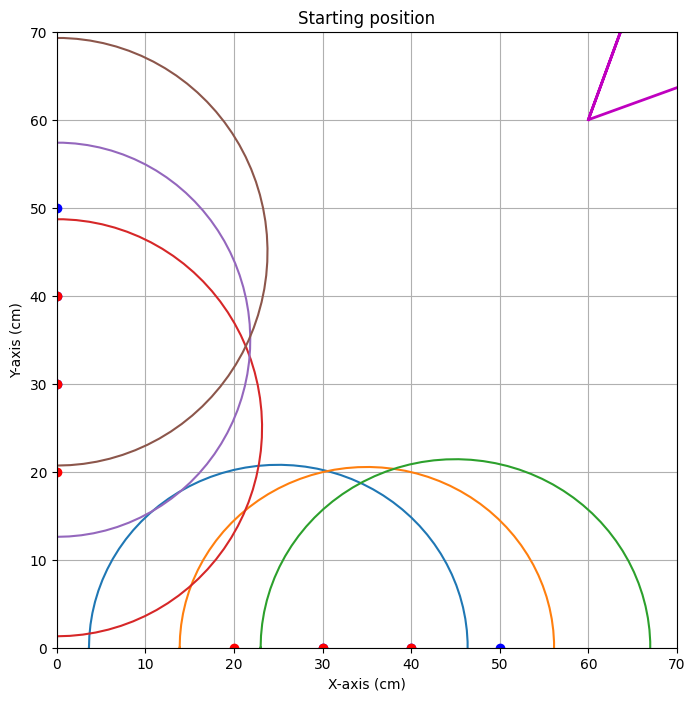


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=93.185


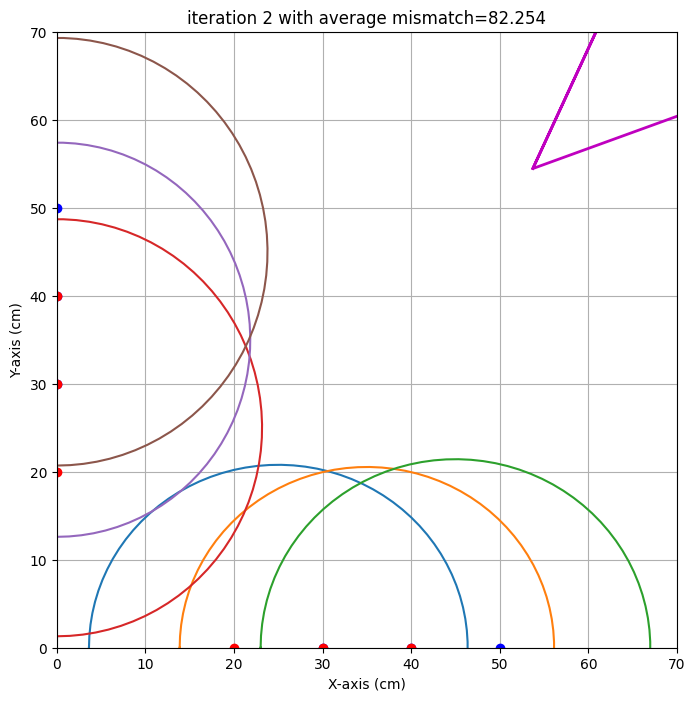

end iteration 2 with average mismatch=82.254


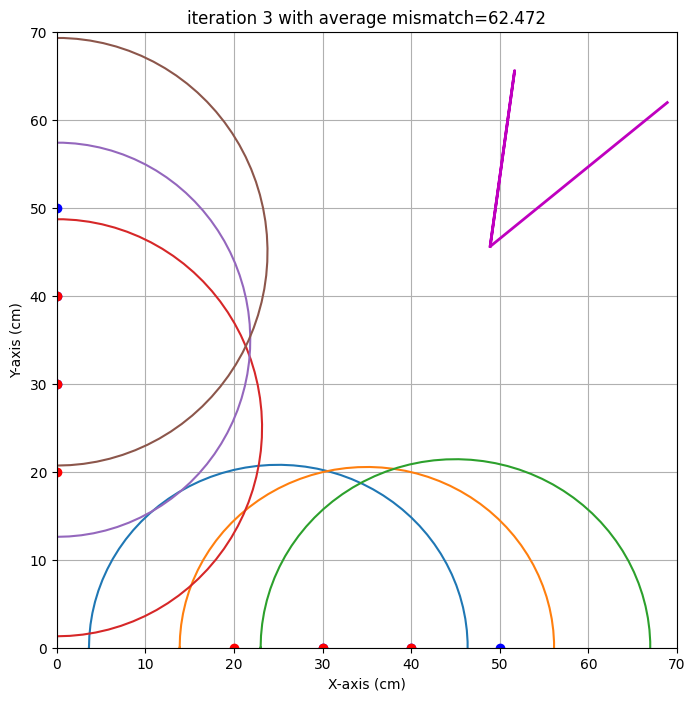

end iteration 3 with average mismatch=62.472


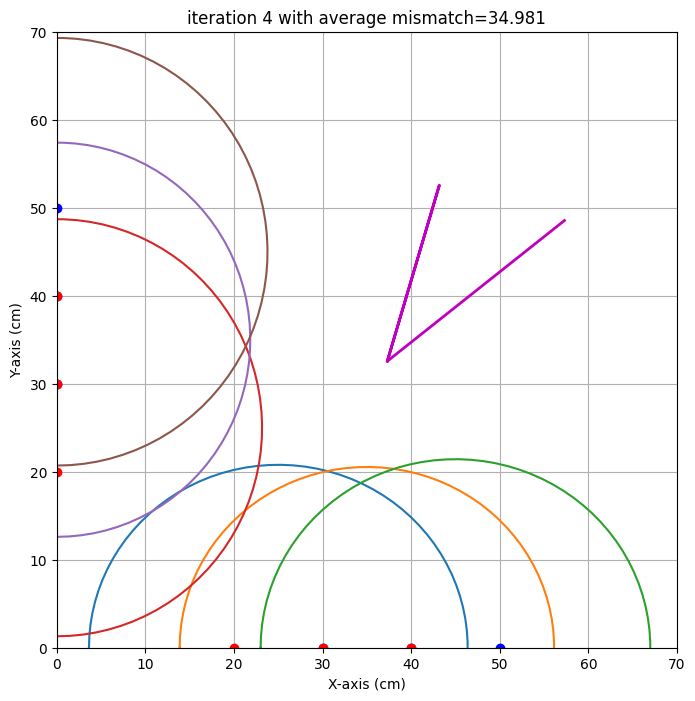

end iteration 4 with average mismatch=34.981


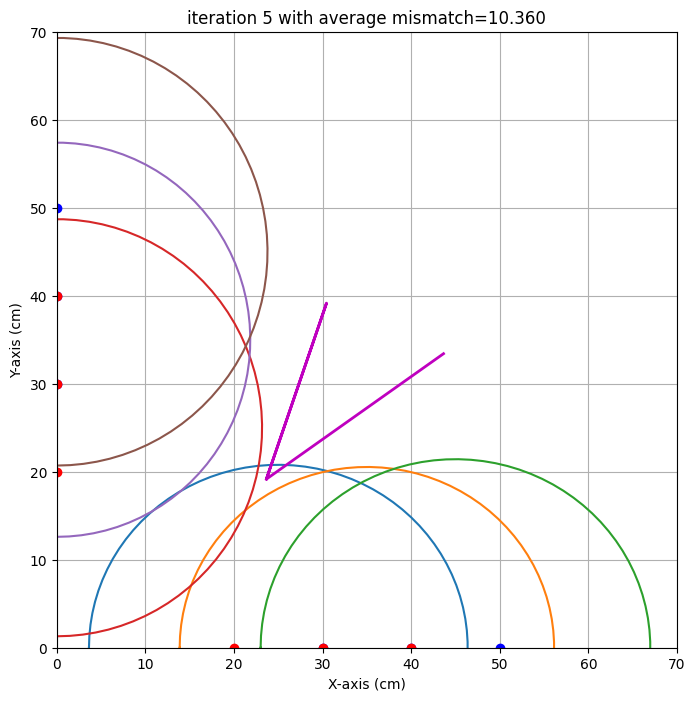

end iteration 5 with average mismatch=10.360


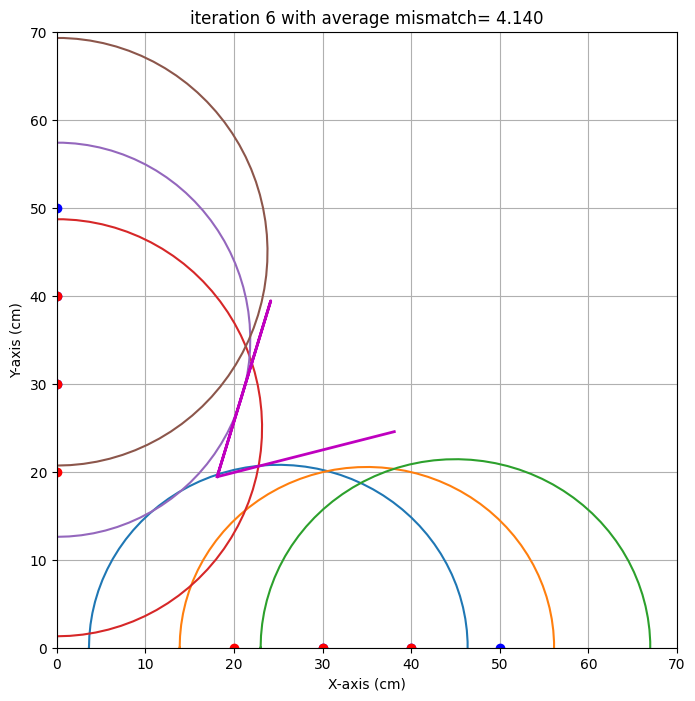

end iteration 6 with average mismatch= 4.140


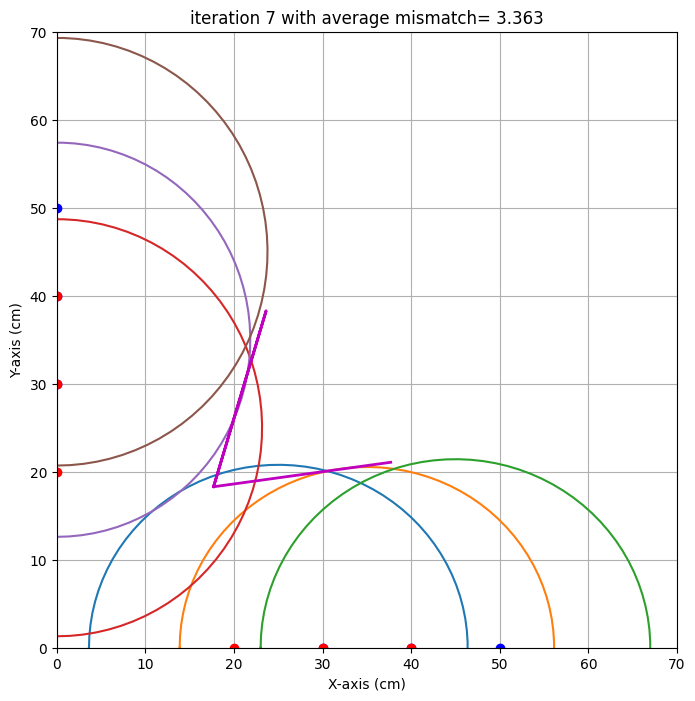

end iteration 7 with average mismatch= 3.363


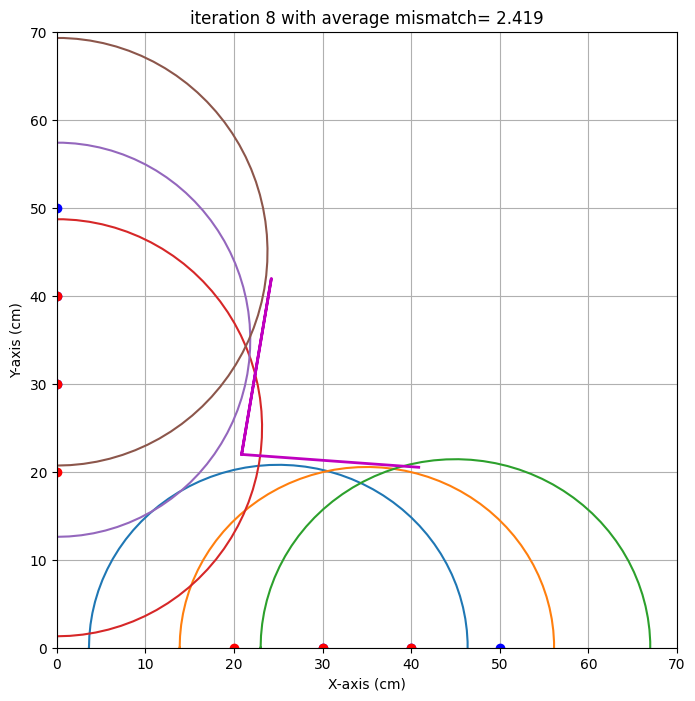

end iteration 8 with average mismatch= 2.419


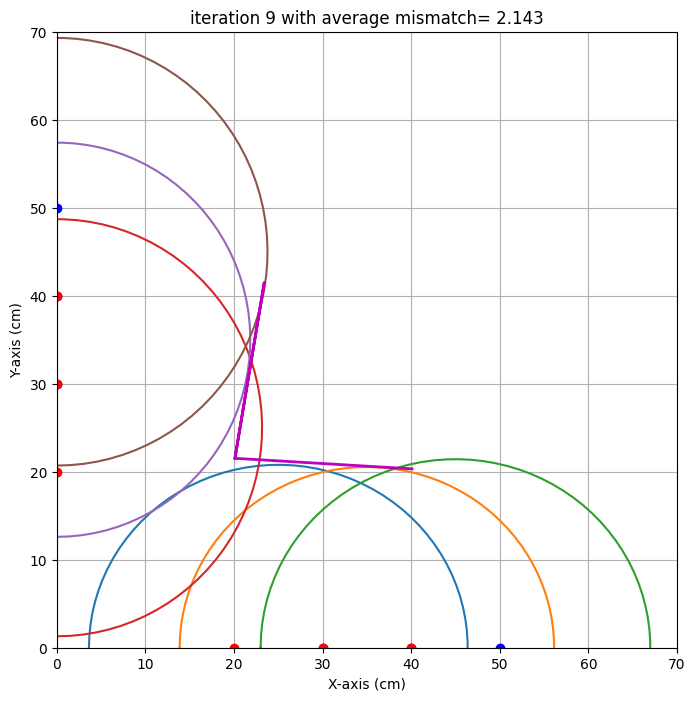

end iteration 9 with average mismatch= 2.143


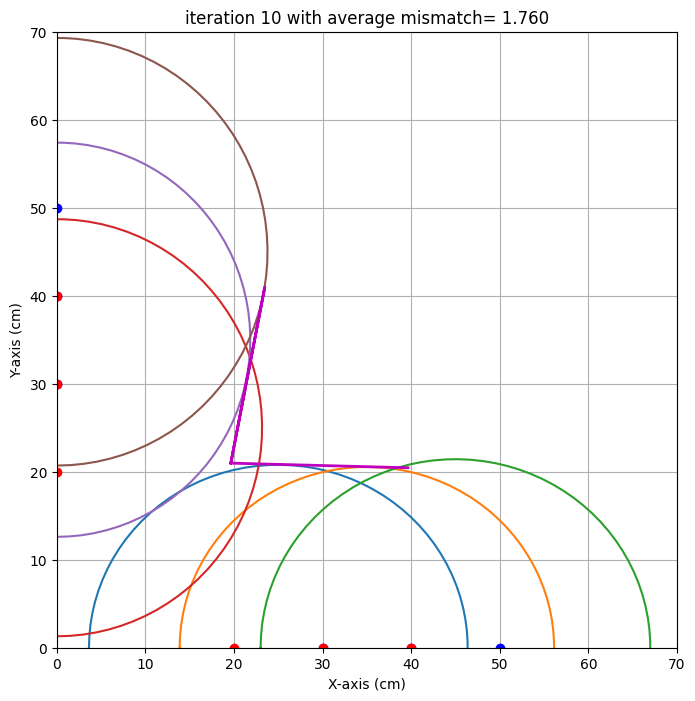

end iteration 10 with average mismatch= 1.760
end iteration 11 with average mismatch= 1.744
end iteration 12 with average mismatch= 1.738
end iteration 13 with average mismatch= 1.737
end iteration 14 with average mismatch= 1.737
end iteration 15 with average mismatch= 1.737
end iteration 16 with average mismatch= 1.737
end iteration 17 with average mismatch= 1.737
end iteration 18 with average mismatch= 1.737
end iteration 19 with average mismatch= 1.737
end iteration 20 with average mismatch= 1.737
end iteration 21 with average mismatch= 1.737
end iteration 22 with average mismatch= 1.737
end iteration 23 with average mismatch= 1.737
end iteration 24 with average mismatch= 1.737
end iteration 25 with average mismatch= 1.737
end iteration 26 with average mismatch= 1.737
end iteration 27 with average mismatch= 1.712
end iteration 28 with average mismatch= 1.707
end iteration 29 with average mismatch= 1.706
Last iteration, also determine uncertainty, wait a while..
wait a little longer.

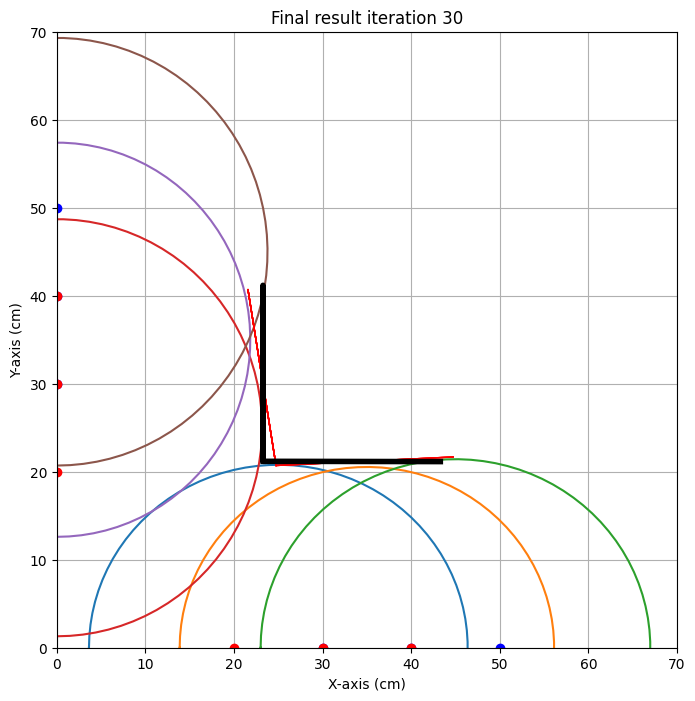

{'alpha': np.float64(-0.09438628274827893), 'alpha_eps': np.float64(2.876526673095273), 'beta': np.float64(-0.0597689155323462), 'beta_eps': np.float64(8.941015938245851), 'x0': np.float64(23.289218731150182), 'x0_eps': np.float64(1.4493454644975472), 'y0': np.float64(21.18290453487037), 'y0_eps': np.float64(0.4772983729184226)}
locatie 3
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  30   0  40  91.2
1   0  40   0  50  90.6
2   0  50   0  60  93.0
3  50   0  60   0  79.6
4  55   0  65   0  82.5
5  60   0  70   0  84.3


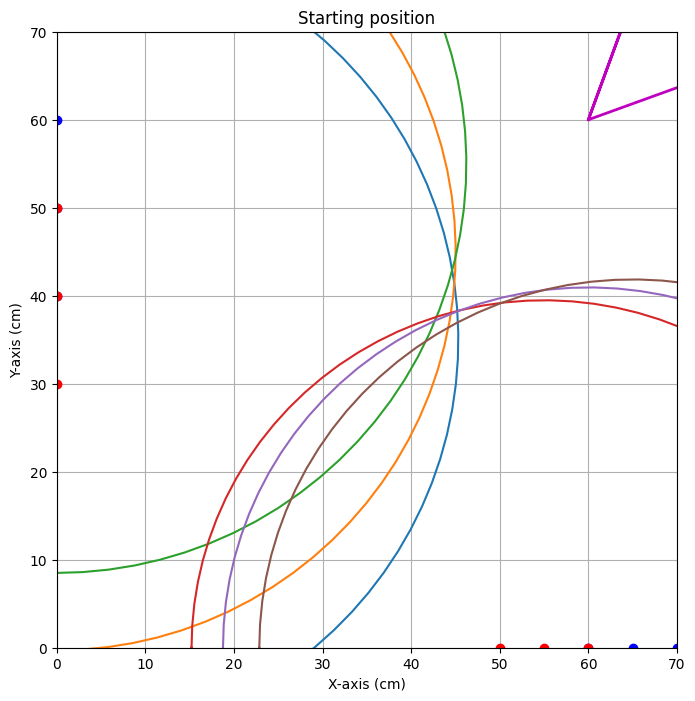


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=42.352


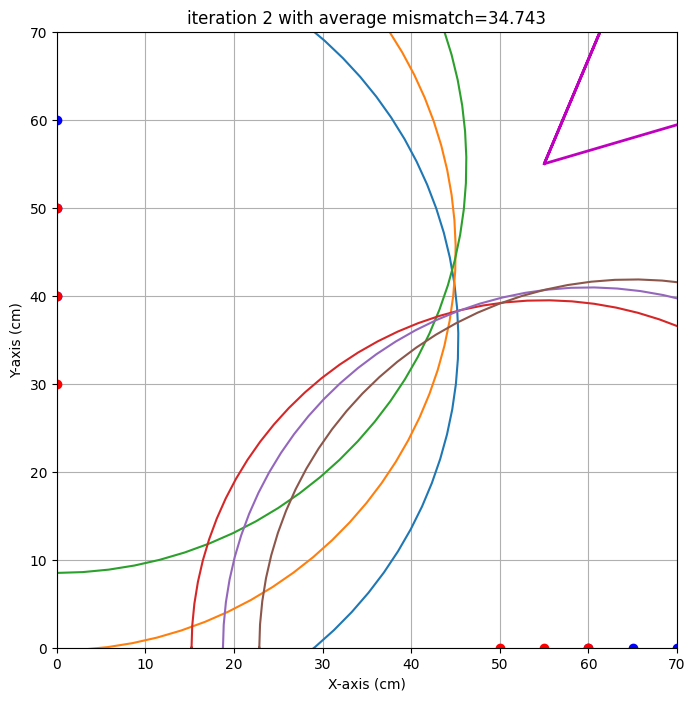

end iteration 2 with average mismatch=34.743


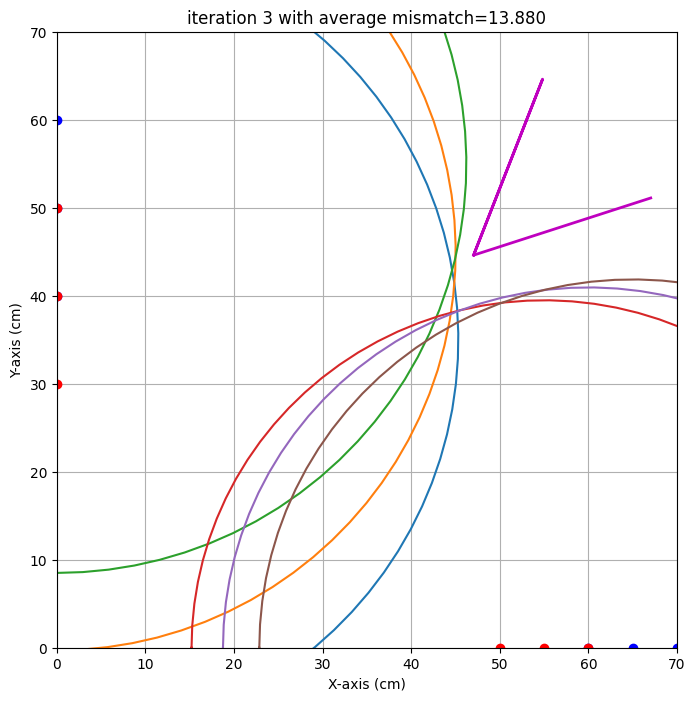

end iteration 3 with average mismatch=13.880


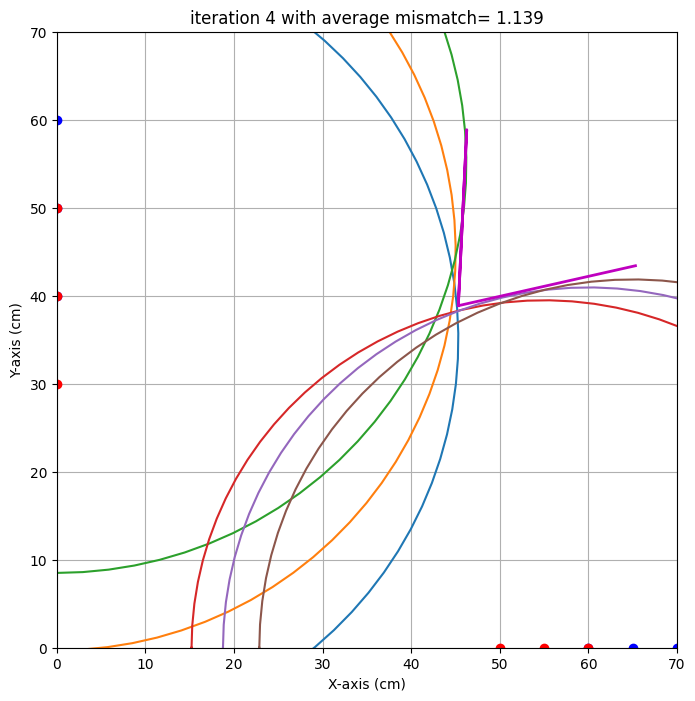

end iteration 4 with average mismatch= 1.139


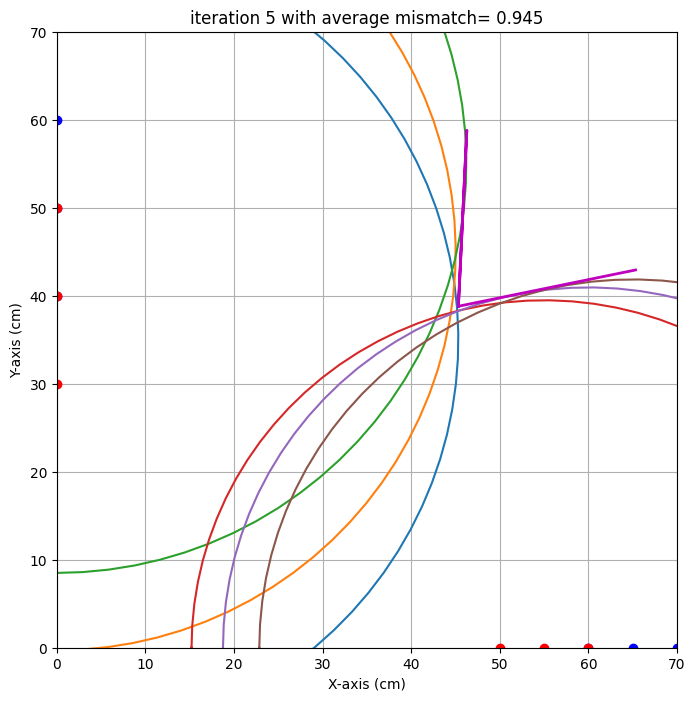

end iteration 5 with average mismatch= 0.945


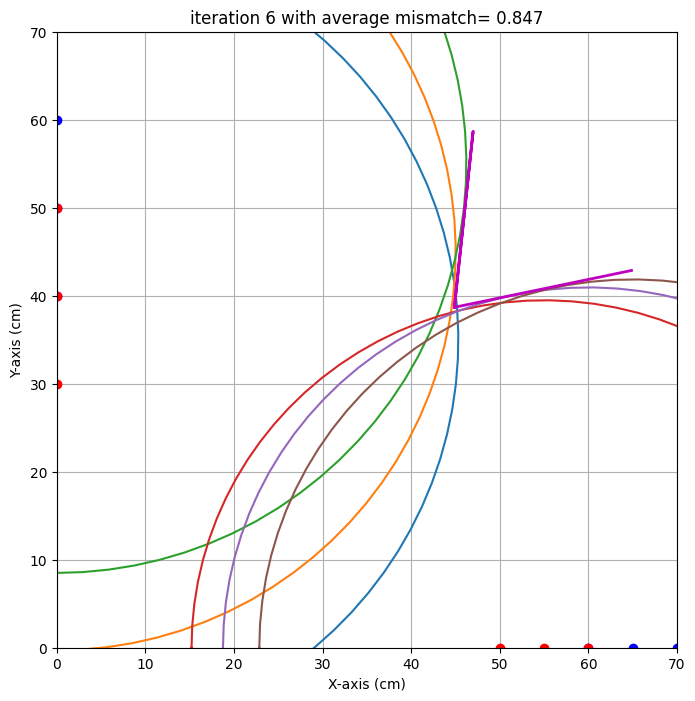

end iteration 6 with average mismatch= 0.847
end iteration 7 with average mismatch= 0.842
end iteration 8 with average mismatch= 0.841
end iteration 9 with average mismatch= 0.841
end iteration 10 with average mismatch= 0.841
end iteration 11 with average mismatch= 0.838
end iteration 12 with average mismatch= 0.835
end iteration 13 with average mismatch= 0.835
end iteration 14 with average mismatch= 0.835
end iteration 15 with average mismatch= 0.835
end iteration 16 with average mismatch= 0.835
end iteration 17 with average mismatch= 0.813
end iteration 18 with average mismatch= 0.787
end iteration 19 with average mismatch= 0.783
end iteration 20 with average mismatch= 0.782
end iteration 21 with average mismatch= 0.781
end iteration 22 with average mismatch= 0.781
end iteration 23 with average mismatch= 0.781
end iteration 24 with average mismatch= 0.745
end iteration 25 with average mismatch= 0.743
end iteration 26 with average mismatch= 0.743
end iteration 27 with average mismatch

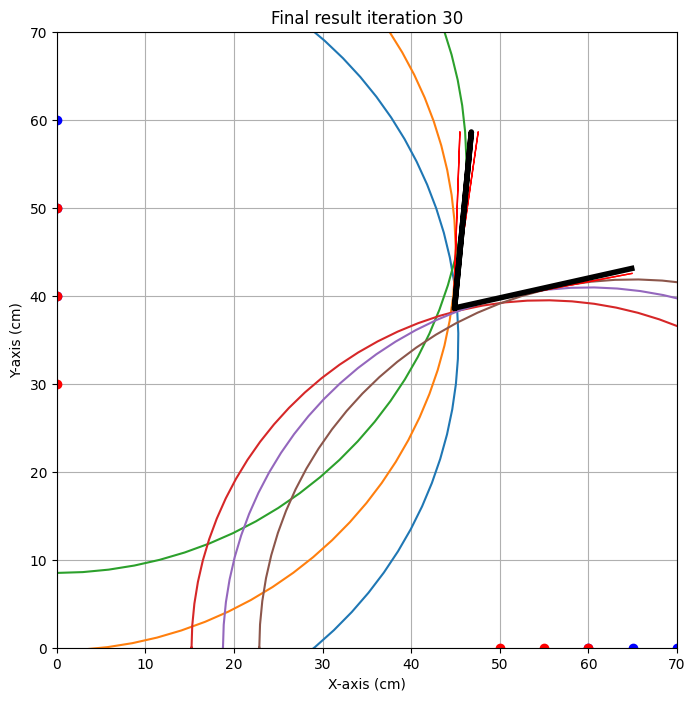

{'alpha': np.float64(12.651564015751125), 'alpha_eps': np.float64(1.8352543103387529), 'beta': np.float64(5.419053489271733), 'beta_eps': np.float64(3.362728793001697), 'x0': np.float64(44.89508799138638), 'x0_eps': np.float64(0.1939441437256022), 'y0': np.float64(38.6057306519901), 'y0_eps': np.float64(0.10730557988681255)}
locatie 1 
x0 target is : 34.6. Gevonden waarde: 25.1 cm met een standaardafwijking van 0.7 cm 
y0 target is : 25.0. Gevonden waarde: 34.9 cm met een standaardafwijking van 0.2 cm 
alpha target is : 0.0. Gevonden waarde: 1.1 graden met een standaardafwijking van 0.9 graad 
beta target is : 4.0. Gevonden waarde: 5.2 graden met een standaardafwijking van 2.4 graad 

locatie 2 
x0 target is : 20.0. Gevonden waarde: 23.3 cm met een standaardafwijking van 1.4 cm 
y0 target is : 25.0. Gevonden waarde: 21.2 cm met een standaardafwijking van 0.5 cm 
alpha target is : 0.0. Gevonden waarde: -0.1 graden met een standaardafwijking van 2.9 graad 
beta target is : 10.0. Gevonden

In [12]:
# Voeg hier je meetgegevens van deze iteratie in:
#________________locatie 1 is iteratie 1 locatie 2 is iteratie 2 .etc_______________________


# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':34.6,#zelf aanvullen,
                    'y0':25, #zelf aanvullen,
                    'alpha' :0, #zelf aanvullen,
                    'beta' :4, #zelf aanvullen}, 
},
           'locatie 2':{'x0':20,#zelf aanvullen,
                    'y0':25, #zelf aanvullen,
                    'alpha' :0, #zelf aanvullen,
                    'beta' :10, #zelf aanvullen
},
            'locatie 3':{
                    'x0': 44,  # zelf aanvullen,
                    'y0': 37,  # zelf aanvullen,
                    'alpha' :10,  # zelf aanvullen,
                    'beta' :11,  # zelf aanvullen
            }}
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    [20,0,30,0,70.67],
    [30,0,40,0,70.7],
    [40,0,50,0,71.2],
    #[50,0,60,0,76.6],
    #[0,20,0,30,0],
    [0,30,0,40,51.5],
    [0,40,0,50,51.9],
    [0,50,0,60,54.5],
    
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [20,0,30,0,42.76],
    [30,0,40,0,42.28],
    [40,0,50,0,44.0],
    #[50,0,60,0,51.4],
    [0,20,0,30,47.40],
    [0,30,0,40,44.80],
    [0,40,0,50,48.6]
    #[0,50,0,60,0],
    ]),
       'locatie 3' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,30,0,40,91.2],
    [0,40,0,50,90.6],
    [0,50,0,60,93.0],
    [50,0,60,0,79.6],
    [55,0,65,0,82.5],
    [60,0,70,0,84.3],
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))